# Master Thesis - Vignoli Lorenzo

---

## 🐙 Helyx training

## ⚙️ Import Libraries

In [1]:
# Libraries
import os
import glob
import random
import warnings
import numpy as np # type: ignore
from sklearn.model_selection import train_test_split # type: ignore

import torch # type: ignore
import torch.nn as nn # type: ignore
import torch.optim as optim # type: ignore
from torch.utils.data import Dataset, DataLoader, RandomSampler # type: ignore
import torch.nn.functional as F # type: ignore
import shutil
import plotly.graph_objects as go # type: ignore
from torch.optim.lr_scheduler import LinearLR, ReduceLROnPlateau # type: ignore
import torchvision.transforms as T
import torchvision.transforms.functional as TF

import matplotlib.pyplot as plt # type: ignore
import seaborn as sns # type: ignore
import matplotlib as mpl # type: ignore
from matplotlib import rcParams # type: ignore
from cycler import cycler # type: ignore
import sys
from torch.amp import GradScaler, autocast # type: ignore

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from scipy.spatial.transform import Rotation as R
from scipy.linalg import solve
from numpy.linalg import lstsq
from scipy.linalg import null_space
import torchvision.models as models
from torchvision.models import mobilenet_v2

# Reconstruction utility
from SINGLE_reconstruction_utility import *

# PCC model
from SINGLE_jacobians import *
from SINGLE_kinematics import *

# Publication-ready plotting setup with LaTeX-like appearance
rcParams.update({
   'figure.figsize': (6, 4), 'figure.dpi': 300, 'savefig.dpi': 300,
   'savefig.format': 'pdf', 'savefig.bbox': 'tight', 'savefig.pad_inches': 0.1,
   'font.family': 'serif', 
   'font.serif': ['Computer Modern Roman', 'CMU Serif', 'Latin Modern Roman', 'DejaVu Serif'],
   'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 11,
   'xtick.labelsize': 10, 'ytick.labelsize': 10, 'legend.fontsize': 10,
   'lines.linewidth': 1.5, 'lines.markersize': 6, 'lines.markeredgewidth': 0.5,
   'axes.linewidth': 1.0, 'axes.spines.top': False, 'axes.spines.right': False,
   'axes.grid': True, 'axes.edgecolor': 'black',
   'xtick.direction': 'in', 'ytick.direction': 'in',
   'xtick.major.size': 4, 'ytick.major.size': 4,
   'xtick.minor.size': 2, 'ytick.minor.size': 2,
   'xtick.minor.visible': True, 'ytick.minor.visible': True,
   'grid.color': 'gray', 'grid.linestyle': '-', 'grid.linewidth': 0.5, 'grid.alpha': 0.3,
   'legend.frameon': True, 'legend.framealpha': 0.9, 'legend.fancybox': False,
   'legend.edgecolor': 'black', 'legend.facecolor': 'white', 'legend.numpoints': 1,
   'text.usetex': True,  # TRUE LaTeX rendering
   'mathtext.default': 'regular',
   'axes.unicode_minus': False,  # Proper minus signs
   'font.weight': 'normal',
   'text.latex.preamble': r'\usepackage{amsmath}\usepackage{amsfonts}\usepackage{amssymb}'
})

sns.set_style("whitegrid", {"axes.spines.left": True, "axes.spines.bottom": True,
                          "axes.spines.top": False, "axes.spines.right": False,
                          "grid.color": "0.8", "grid.linestyle": "-", "grid.linewidth": 0.5})
pub_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
             '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
sns.set_palette(pub_colors)
rcParams['axes.prop_cycle'] = cycler('color', pub_colors)

# Ignore warnings
warnings.filterwarnings("ignore")
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Additional function to make text more LaTeX-like
def latex_style_text(text):
    """Convert text to use LaTeX-style formatting with matplotlib's mathtext"""
    return rf"${text}$" if not text.startswith('$') else text

print("LaTeX-like setup loaded. Use r'$\\alpha$' syntax for math symbols.")

Using device: cuda
LaTeX-like setup loaded. Use r'$\alpha$' syntax for math symbols.


## ⏳ Load and process the Data

In [2]:
if False:

    for split in ["train", "val", "test"]:
        shutil.rmtree(f"images/{split}", ignore_errors=True)
        shutil.rmtree(f"y/{split}", ignore_errors=True)
        shutil.rmtree(f"DELTAL/{split}", ignore_errors=True)
        shutil.rmtree(f"quad/{split}", ignore_errors=True)
        shutil.rmtree(f"affine/{split}", ignore_errors=True)
        shutil.rmtree(f"const/{split}", ignore_errors=True)
        shutil.rmtree(f"poly/{split}", ignore_errors=True)
        os.makedirs(f"images/{split}", exist_ok=True)
        os.makedirs(f"y/{split}", exist_ok=True)
        os.makedirs(f"DELTAL/{split}", exist_ok=True)
        os.makedirs(f"quad/{split}", exist_ok=True)
        os.makedirs(f"affine/{split}", exist_ok=True)
        os.makedirs(f"const/{split}", exist_ok=True)
        os.makedirs(f"poly/{split}", exist_ok=True)

    dataset_files = sorted(glob.glob("Dataset*.pt"))
    total_originals = sum([len(torch.load(f)["X_images"]) for f in dataset_files])
    all_indices = np.arange(total_originals)

    train_idx, temp_idx = train_test_split(all_indices, test_size=0.15)
    val_idx, test_idx = train_test_split(temp_idx, test_size=1/3)

    split_map = np.full(total_originals, "", dtype=object)
    split_map[train_idx] = "train"
    split_map[val_idx] = "val"
    split_map[test_idx] = "test"

    global_index = {
        "train": 0,
        "val": 0,
        "test": 0
    }

    current_idx = 0

    for file in dataset_files:

        # Process each dataset file
        print(f"\n Processing {file}...")
        data = torch.load(file)
        X_images = data["X_images"]
        y = data["y"]
        X_DELTAL = data["X_DELTAL"]
        quad = data["X_quad"]
        affine = data["X_affine"]
        const = data["X_const"]
        poly = data["X_poly"]

        for i in range(len(X_images)):

            split = split_map[current_idx]
            idx_str = f"{global_index[split]:06d}"

            # Save tensors to respective directories
            torch.save(X_images[i], f"images/{split}/img_{idx_str}.pt")
            torch.save(y[i],         f"y/{split}/y_{idx_str}.pt")
            torch.save(X_DELTAL[i],  f"DELTAL/{split}/deltal_{idx_str}.pt")
            torch.save(quad[i], f"quad/{split}/quad_{idx_str}.pt")
            torch.save(affine[i], f"affine/{split}/affine_{idx_str}.pt")
            torch.save(const[i], f"const/{split}/const_{idx_str}.pt")
            torch.save(poly[i], f"poly/{split}/poly_{idx_str}.pt")

            global_index[split] += 1
            current_idx += 1

            percent = (current_idx / total_originals) * 100
            sys.stdout.write(f"\rProgress: {percent:.2f}%")
            sys.stdout.flush()

        del X_images, y, X_DELTAL, quad, affine, const, poly

    # Print inputs and labels, to reconstruct inverse kinematics
    for split in ["train", "val", "test"]:
        shutil.rmtree(f"inputs/{split}", ignore_errors=True)
        shutil.rmtree(f"labels/{split}", ignore_errors=True)
        os.makedirs(f"inputs/{split}", exist_ok=True)
        os.makedirs(f"labels/{split}", exist_ok=True)

    dataset_files = sorted(glob.glob("Dataset*.pt"))
    total_originals = sum([len(torch.load(f)["X_images"]) for f in dataset_files])
    all_indices = np.arange(total_originals)

    train_idx, temp_idx = train_test_split(all_indices, test_size=0.15)
    val_idx, test_idx = train_test_split(temp_idx, test_size=1/3)

    split_map = np.full(total_originals, "", dtype=object)
    split_map[train_idx] = "train"
    split_map[val_idx] = "val"
    split_map[test_idx] = "test"

    global_index = {
        "train": 0,
        "val": 0,
        "test": 0
    }

    current_idx = 0

    for file in dataset_files:

        print(f"\n Processing {file}...")
        data = torch.load(file)
        y = data["y"]
        X_DELTAL = data["X_DELTAL"]

        for i in range(len(y)):

            split = split_map[current_idx]
            input_tensor = y[i][:3]
            label_tensor = X_DELTAL[i]

            idx_str = f"{global_index[split]:06d}"

            torch.save(input_tensor, f"inputs/{split}/input_{idx_str}.pt")
            torch.save(label_tensor, f"labels/{split}/label_{idx_str}.pt")

            global_index[split] = global_index[split] + 1
            current_idx += 1

            percent = (current_idx / total_originals) * 100
            sys.stdout.write(f"\rProgress: {percent:.2f}%")
            sys.stdout.flush()

        del y
        del X_DELTAL

    print("\n Finished dataset generation.")

In [3]:
# Save summary statistics for normalization
if False:
    # --- y (target position + orientation) ---
    y_paths = sorted(glob.glob("y/train/*.pt"))
    all_y = torch.stack([torch.load(p).float() for p in y_paths])
    mean_y = all_y.mean(dim=0)
    std_y = all_y.std(dim=0)
    torch.save({'mean': mean_y, 'std': std_y}, 'label_stats.pt')
    del all_y, mean_y, std_y

    # --- quad (shape descriptors) ---
    backbone_paths = sorted(glob.glob("quad/train/*.pt"))
    all_backbones = torch.stack([torch.load(p).float().view(-1) for p in backbone_paths])
    mean_backbone = all_backbones.mean(dim=0)
    std_backbone = all_backbones.std(dim=0)
    torch.save({'mean': mean_backbone, 'std': std_backbone}, 'quad_stats.pt')
    del all_backbones, mean_backbone, std_backbone

    # --- affine (shape descriptors) ---
    backbone_paths = sorted(glob.glob("affine/train/*.pt"))
    all_backbones = torch.stack([torch.load(p).float().view(-1) for p in backbone_paths])
    mean_backbone = all_backbones.mean(dim=0)
    std_backbone = all_backbones.std(dim=0)
    torch.save({'mean': mean_backbone, 'std': std_backbone}, 'affine_stats.pt')
    del all_backbones, mean_backbone, std_backbone

    # --- const (shape descriptors) ---
    backbone_paths = sorted(glob.glob("const/train/*.pt"))
    all_backbones = torch.stack([torch.load(p).float().view(-1) for p in backbone_paths])
    mean_backbone = all_backbones.mean(dim=0)
    std_backbone = all_backbones.std(dim=0)
    torch.save({'mean': mean_backbone, 'std': std_backbone}, 'const_stats.pt')
    del all_backbones, mean_backbone, std_backbone

    # --- poly (shape descriptors) ---
    backbone_paths = sorted(glob.glob("poly/train/*.pt"))
    all_backbones = torch.stack([torch.load(p).float().view(-1) for p in backbone_paths])
    mean_backbone = all_backbones.mean(dim=0)
    std_backbone = all_backbones.std(dim=0)
    torch.save({'mean': mean_backbone, 'std': std_backbone}, 'poly_stats.pt')
    del all_backbones, mean_backbone, std_backbone

    # --- inverse kinematics ---
    label_paths = sorted(glob.glob("labels/train/*.pt"))
    all_labels = torch.stack([torch.load(p).float() for p in label_paths])
    mean = all_labels.mean(dim=0)
    std = all_labels.std(dim=0)
    torch.save({'mean': mean, 'std': std}, 'deltal_stats.pt')
    del mean, std
    

## ⏳ Dataset generation

In [4]:
class ImageRegressionDataset(Dataset):
    def __init__(self, image_paths, label_paths, split="train"):
        self.image_paths = image_paths
        self.label_paths = label_paths
        self.augment = split == "train"

    def __len__(self):
        return len(self.image_paths)

    def apply_blur(self, image, kernel_size=5, sigma_max=8.0):
        sigma = random.uniform(0.0, sigma_max)
        image = image.float().unsqueeze(0) / 255.0
        image = TF.gaussian_blur(image, kernel_size=kernel_size, sigma=sigma)
        return (image.squeeze(0) * 255.0).clamp(0, 255).to(torch.uint8)

    def add_gaussian_noise(self, image, std_max=30.0):
        std = random.uniform(0.0, std_max)
        noise = torch.randn_like(image.float()) * std
        image = image.float() + noise
        return image.clamp(0, 255).to(torch.uint8)

    def apply_color_jitter(self, image, brightness=0.4, contrast=0.4):
        image = image.float().unsqueeze(0) / 255.0
        b = 1.0 + random.uniform(-brightness, brightness)
        c = 1.0 + random.uniform(-contrast, contrast)
        image = TF.adjust_brightness(image, b)
        image = TF.adjust_contrast(image, c)
        return (image.squeeze(0) * 255.0).clamp(0, 255).to(torch.uint8)

    def apply_brightness_shift(self, image, offset_max=0.3):
        offset = random.choice([-offset_max, offset_max])
        image = (image.float() / 255.0 + offset).clamp(0.0, 1.0)
        return (image * 255.0).to(torch.uint8)

    def apply_vignette(self, image, strength_max=0.6):
        strength = strength_max
        H, W = image.shape[1:]
        Y, X = torch.meshgrid(torch.linspace(-1, 1, H), torch.linspace(-1, 1, W), indexing='ij')
        radius = torch.sqrt(X**2 + Y**2)
        mask = 1.0 - strength * radius**2
        mask = mask.clamp(0.75, 1.0).unsqueeze(0)
        image = (image.float() / 255.0 * mask).clamp(0.0, 1.0)
        return (image * 255.0).to(torch.uint8)
    
    def apply_cutout(self, image, num_patches_range=(1, 3), max_ratio=0.5):
        C, H, W = image.shape
        num_patches = random.randint(*num_patches_range)
        for _ in range(num_patches):
            patch_h = int(random.uniform(0.0, max_ratio) * H)
            patch_w = int(random.uniform(0.0, max_ratio) * W)
            if patch_h == 0 or patch_w == 0:
                continue
            top = random.randint(0, H - patch_h)
            left = random.randint(0, W - patch_w)
            image[:, top:top + patch_h, left:left + patch_w] = 0  # black patch
        return image

    def __getitem__(self, idx):
        image = torch.load(self.image_paths[idx]).to(torch.uint8)
        label = torch.load(self.label_paths[idx]).float()

        if self.augment:
            image = self.apply_blur(image)
            image = self.add_gaussian_noise(image)
            image = self.apply_color_jitter(image)
            image = self.apply_brightness_shift(image)
            image = self.apply_vignette(image)
            image = self.apply_cutout(image)

        label = label.view(-1)

        return image, label
    
# Generic path loader for images + target (y or backbones)
def get_paths(split, target_folder):
    image_dir = os.path.join("images", split)
    target_dir = os.path.join(target_folder, split)
    image_paths = sorted([
        os.path.join(image_dir, f) for f in os.listdir(image_dir) if f.endswith(".pt")
    ])
    target_paths = sorted([
        os.path.join(target_dir, f) for f in os.listdir(target_dir) if f.endswith(".pt")
    ])
    assert len(image_paths) == len(target_paths), f"Mismatch in {split} set"
    return image_paths, target_paths

In [5]:
class DELTALRegressionDataset(Dataset):
    def __init__(self, input_paths, label_paths):
        self.input_paths = input_paths
        self.label_paths = label_paths

    def __len__(self):
        return len(self.input_paths)

    def __getitem__(self, idx):
        input_tensor = torch.load(self.input_paths[idx]).float()
        label_tensor = torch.load(self.label_paths[idx]).float()
        return input_tensor, label_tensor

# Generic path loader for inverse kinematics (IK) inputs and labels
def get_paths_IK(split):
    input_dir = os.path.join("inputs", split)
    label_dir = os.path.join("labels", split)
    input_paths = sorted([os.path.join(input_dir, f) for f in os.listdir(input_dir) if f.endswith(".pt")])
    label_paths = sorted([os.path.join(label_dir, f) for f in os.listdir(label_dir) if f.endswith(".pt")])
    assert len(input_paths) == len(label_paths)
    return input_paths, label_paths

In [8]:
class CurvatureRegressionDataset(Dataset):
    def __init__(self, input_paths, label_paths):
        self.input_paths = input_paths
        self.label_paths = label_paths

    def __len__(self):
        return len(self.input_paths)

    def __getitem__(self, idx):
        pose_path, deltal_path = self.input_paths[idx]
        pose = torch.load(pose_path).float()
        deltal = torch.load(deltal_path).float()
        input_tensor = torch.cat([pose, deltal], dim=-1)
        label_tensor = torch.load(self.label_paths[idx]).float()
        return input_tensor, label_tensor

def get_paths_curvature(split, mode='quadratic'):
    input_dir_p = os.path.join("y", split)
    input_dir_l = os.path.join("DELTAL", split)
    if mode == 'affine':
        label_dir = os.path.join("affine", split)
    elif mode == 'constant':
        label_dir = os.path.join("const", split)
    else:
        label_dir = os.path.join("quad", split)
    pose_paths = sorted([os.path.join(input_dir_p, f) for f in os.listdir(input_dir_p) if f.endswith(".pt")])
    deltal_paths = sorted([os.path.join(input_dir_l, f) for f in os.listdir(input_dir_l) if f.endswith(".pt")])
    label_paths = sorted([os.path.join(label_dir, f) for f in os.listdir(label_dir) if f.endswith(".pt")])
    assert len(pose_paths) == len(deltal_paths) == len(label_paths)
    input_paths = list(zip(pose_paths, deltal_paths))
    return input_paths, label_paths


In [9]:
# === First stage: training on y ===
train_img_y, train_lbl_y = get_paths("train", "y")
val_img_y, val_lbl_y = get_paths("val", "y")
test_img_y, test_lbl_y = get_paths("test", "y")

train_dataset_y = ImageRegressionDataset(train_img_y, train_lbl_y, split="train")
val_dataset_y = ImageRegressionDataset(val_img_y, val_lbl_y, split="val")
test_dataset_y = ImageRegressionDataset(test_img_y, test_lbl_y, split="test")

# Shared sampler
shared_sampler = RandomSampler(train_dataset_y)

train_loader_y = DataLoader(train_dataset_y, batch_size=16, sampler=shared_sampler,
                            num_workers=12, pin_memory=True, persistent_workers=True)
val_loader_y = DataLoader(val_dataset_y, batch_size=16, shuffle=False,
                          num_workers=12, pin_memory=True, persistent_workers=True)
test_loader_y = DataLoader(test_dataset_y, batch_size=16, shuffle=False,
                           num_workers=12, pin_memory=True, persistent_workers=True)

# === Second stage: training on shape descriptors ===
target_folders = ["quad", "affine", "const", "poly"]
loaders = {}

# To use it, e.g. loaders["quad"]["train"], for all target folders
for target in target_folders:
    train_img, train_lbl = get_paths("train", target)
    val_img, val_lbl = get_paths("val", target)
    test_img, test_lbl = get_paths("test", target)

    train_ds = ImageRegressionDataset(train_img, train_lbl, split="train")
    val_ds = ImageRegressionDataset(val_img, val_lbl, split="val")
    test_ds = ImageRegressionDataset(test_img, test_lbl, split="test")

    train_loader = DataLoader(train_ds, batch_size=16, sampler=shared_sampler,
                              num_workers=12, pin_memory=True, persistent_workers=True)
    val_loader = DataLoader(val_ds, batch_size=16, shuffle=False,
                            num_workers=12, pin_memory=True, persistent_workers=True)
    test_loader = DataLoader(test_ds, batch_size=16, shuffle=False,
                             num_workers=12, pin_memory=True, persistent_workers=True)

    loaders[target] = {
        "train": train_loader,
        "val": val_loader,
        "test": test_loader
    }

# === Third stage: inverse kinematics ===
train_inputs, train_labels = get_paths_IK("train")
val_inputs, val_labels = get_paths_IK("val")
test_inputs, test_labels = get_paths_IK("test")

train_dataset = DELTALRegressionDataset(train_inputs, train_labels)
val_dataset = DELTALRegressionDataset(val_inputs, val_labels)
test_dataset = DELTALRegressionDataset(test_inputs, test_labels)

train_loader_IK = DataLoader(train_dataset, batch_size=64, shuffle=True,
                          num_workers=12, pin_memory=True, persistent_workers=True)
val_loader_IK = DataLoader(val_dataset, batch_size=64, shuffle=False,
                        num_workers=12, pin_memory=True, persistent_workers=True)
test_loader_IK = DataLoader(test_dataset, batch_size=64, shuffle=False,
                         num_workers=12, pin_memory=True, persistent_workers=True)

# === Fourth stage: curvature regression ===
train_inputs_quad, train_labels_quad = get_paths_curvature("train", mode='quadratic')
val_inputs_quad, val_labels_quad = get_paths_curvature("val", mode='quadratic')
test_inputs_quad, test_labels_quad = get_paths_curvature("test", mode='quadratic')

train_inputs_affine, train_labels_affine = get_paths_curvature("train", mode='affine')
val_inputs_affine, val_labels_affine = get_paths_curvature("val", mode='affine')
test_inputs_affine, test_labels_affine = get_paths_curvature("test", mode='affine')

train_inputs_const, train_labels_const = get_paths_curvature("train", mode='constant')
val_inputs_const, val_labels_const = get_paths_curvature("val", mode='constant')
test_inputs_const, test_labels_const = get_paths_curvature("test", mode='constant')

train_dataset_quad = CurvatureRegressionDataset(train_inputs_quad, train_labels_quad)
val_dataset_quad = CurvatureRegressionDataset(val_inputs_quad, val_labels_quad)
test_dataset_quad = CurvatureRegressionDataset(test_inputs_quad, test_labels_quad)

train_dataset_affine = CurvatureRegressionDataset(train_inputs_affine, train_labels_affine)
val_dataset_affine = CurvatureRegressionDataset(val_inputs_affine, val_labels_affine)
test_dataset_affine = CurvatureRegressionDataset(test_inputs_affine, test_labels_affine)

train_dataset_const = CurvatureRegressionDataset(train_inputs_const, train_labels_const)
val_dataset_const = CurvatureRegressionDataset(val_inputs_const, val_labels_const)
test_dataset_const = CurvatureRegressionDataset(test_inputs_const, test_labels_const)

train_loader_quad = DataLoader(train_dataset_quad, batch_size=64, shuffle=True,
                               num_workers=12, pin_memory=True, persistent_workers=True)
val_loader_quad = DataLoader(val_dataset_quad, batch_size=64, shuffle=False,
                             num_workers=12, pin_memory=True, persistent_workers=True)
test_loader_quad = DataLoader(test_dataset_quad, batch_size=64, shuffle=False,
                              num_workers=12, pin_memory=True, persistent_workers=True)

train_loader_affine = DataLoader(train_dataset_affine, batch_size=64, shuffle=True,
                                 num_workers=12, pin_memory=True, persistent_workers=True)
val_loader_affine = DataLoader(val_dataset_affine, batch_size=64, shuffle=False,
                               num_workers=12, pin_memory=True, persistent_workers=True)
test_loader_affine = DataLoader(test_dataset_affine, batch_size=64, shuffle=False,
                                num_workers=12, pin_memory=True, persistent_workers=True)

train_loader_const = DataLoader(train_dataset_const, batch_size=64, shuffle=True,
                                num_workers=12, pin_memory=True, persistent_workers=True)
val_loader_const = DataLoader(val_dataset_const, batch_size=64, shuffle=False,
                              num_workers=12, pin_memory=True, persistent_workers=True)
test_loader_const = DataLoader(test_dataset_const, batch_size=64, shuffle=False,
                               num_workers=12, pin_memory=True, persistent_workers=True)

## ⚓ Augmentations visualization

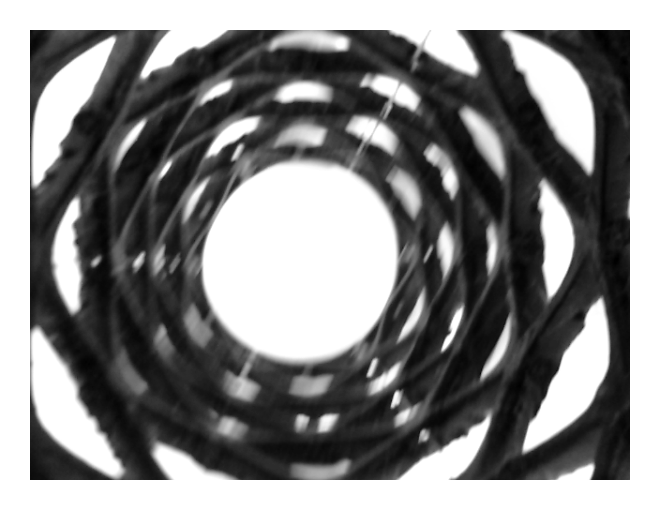

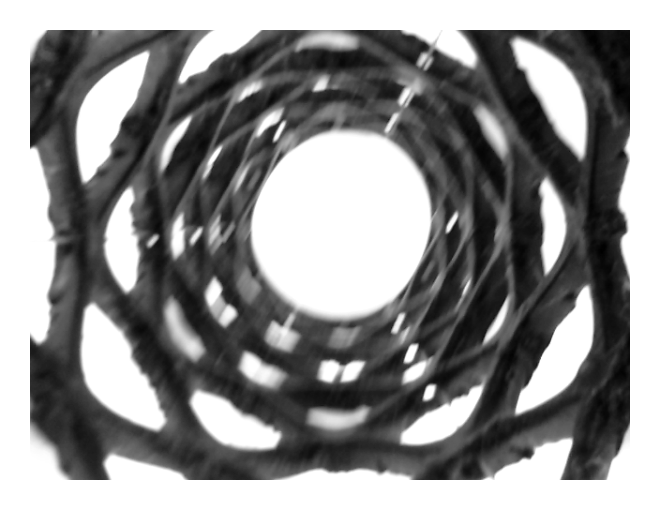

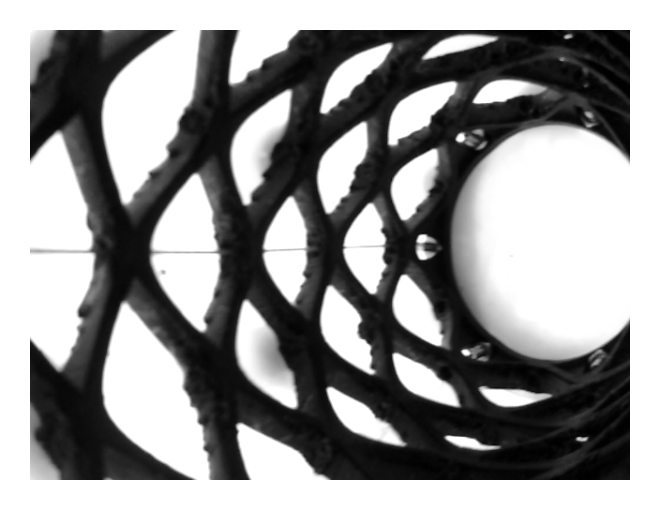

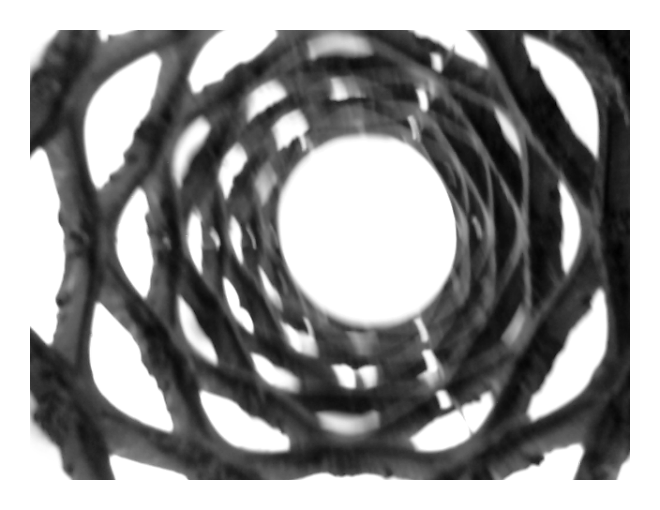

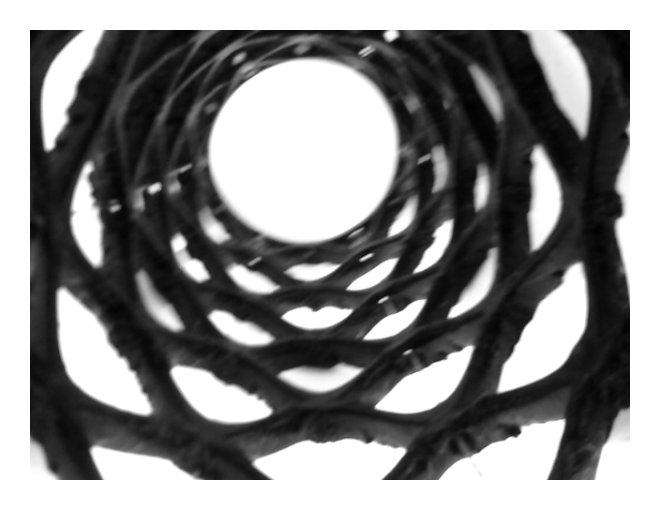

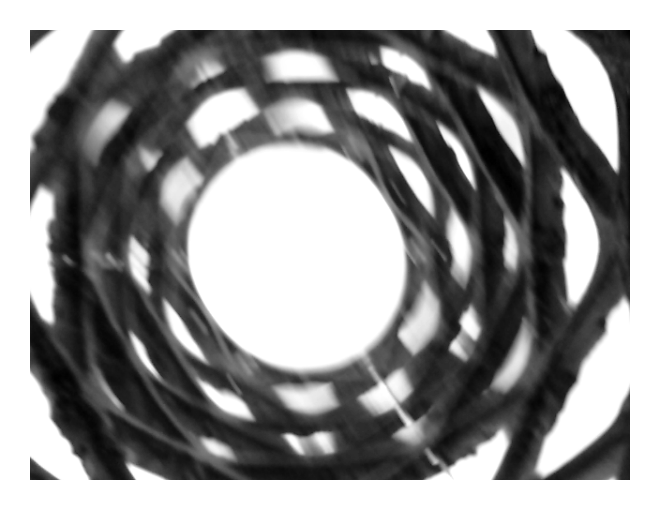

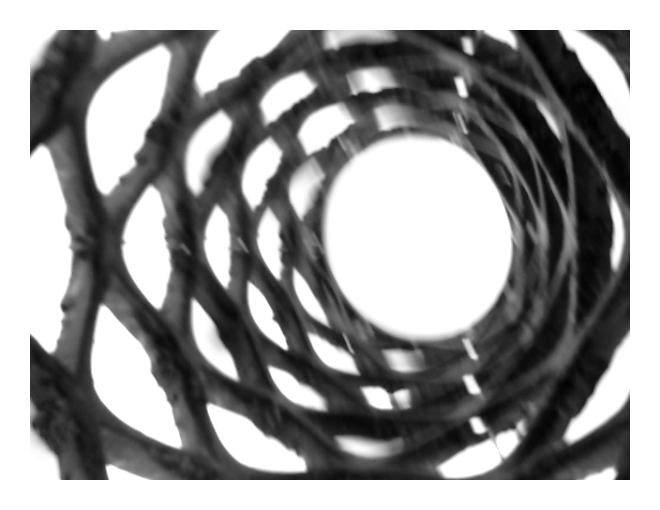

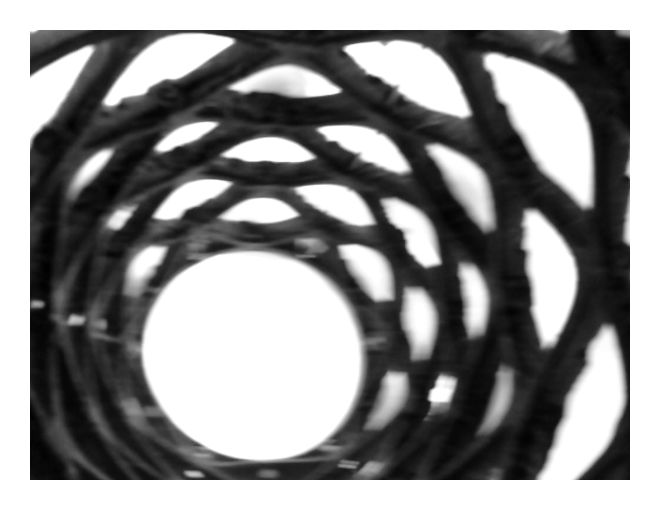

In [8]:
# Load random images for publication display
paths = sorted(glob.glob("images/train/*.pt"))
N_PATHS = 8

for i in range(N_PATHS):
    path = random.choice(paths)
    image = torch.load(path).float() / 255.0  # [3, H, W]
    
    # Create publication-quality figure
    fig, ax = plt.subplots(1, 1, figsize=(2, 2))
    
    # Display image without axes, titles, or borders
    ax.imshow(image.squeeze(0).cpu(), cmap='gray', aspect='equal')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
    plt.show()

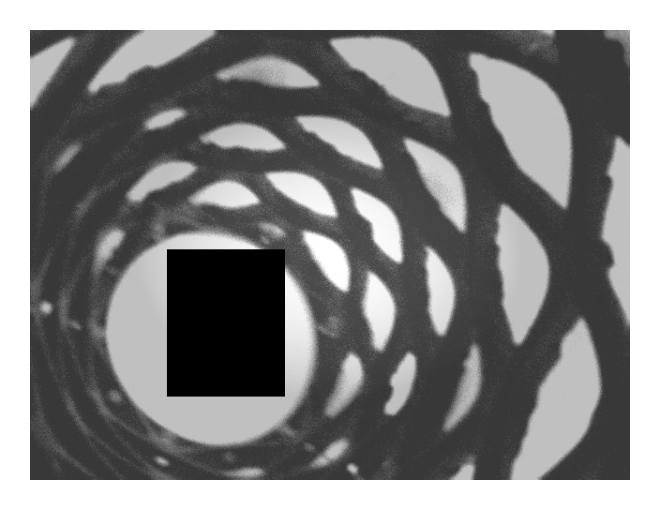

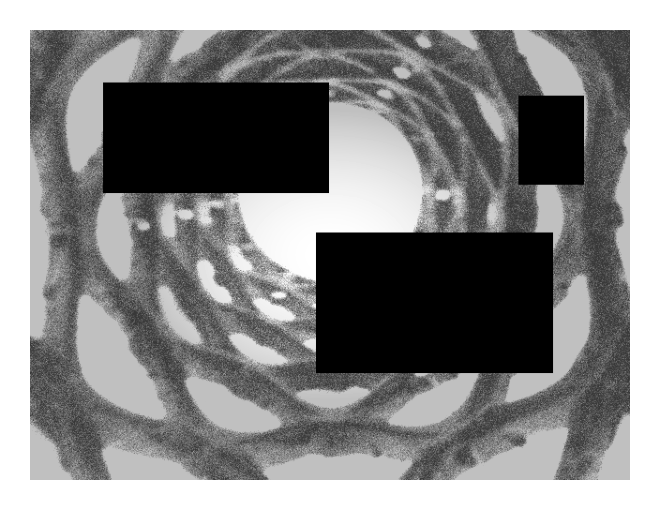

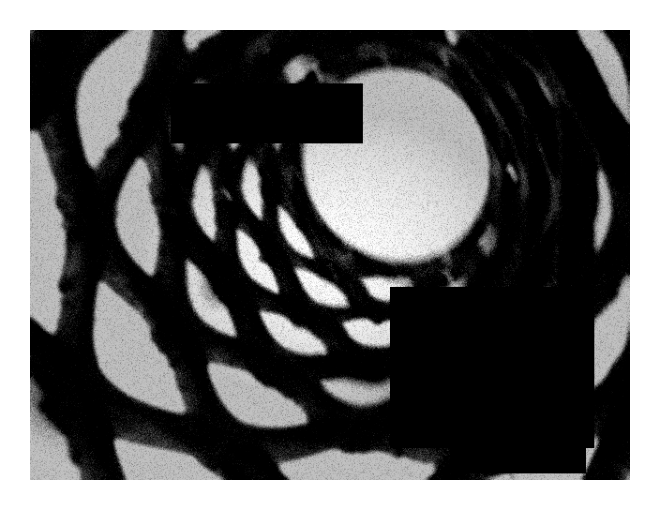

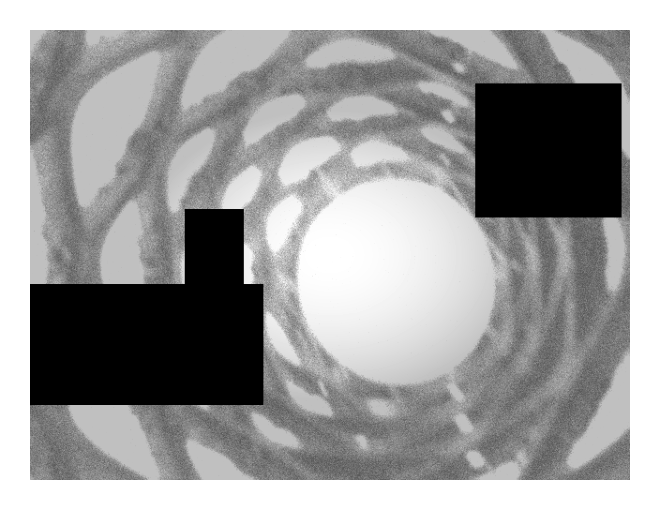

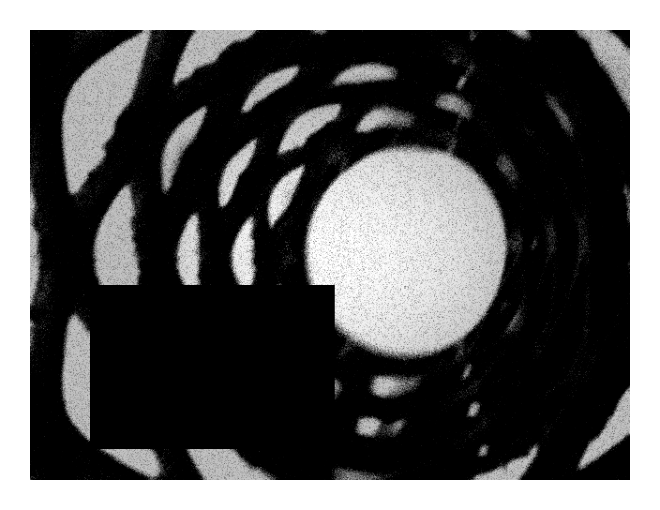

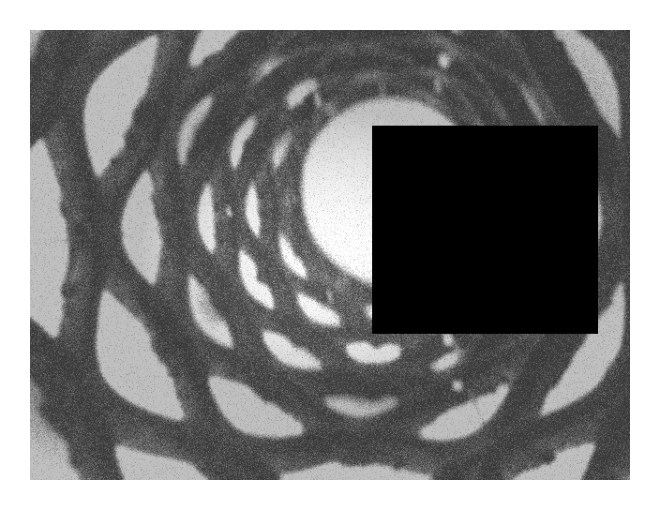

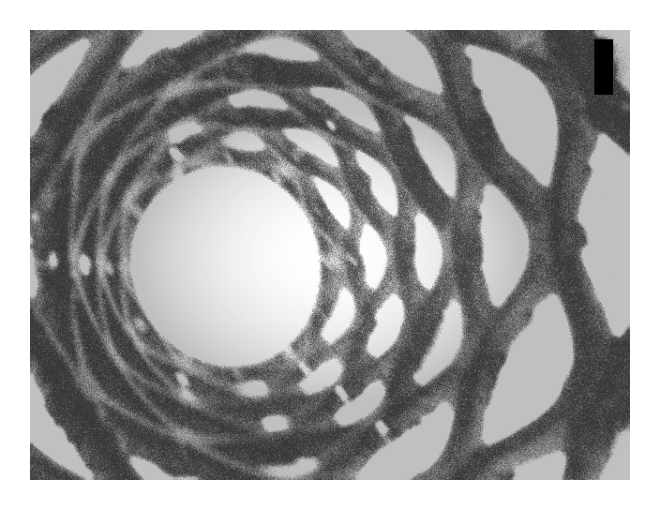

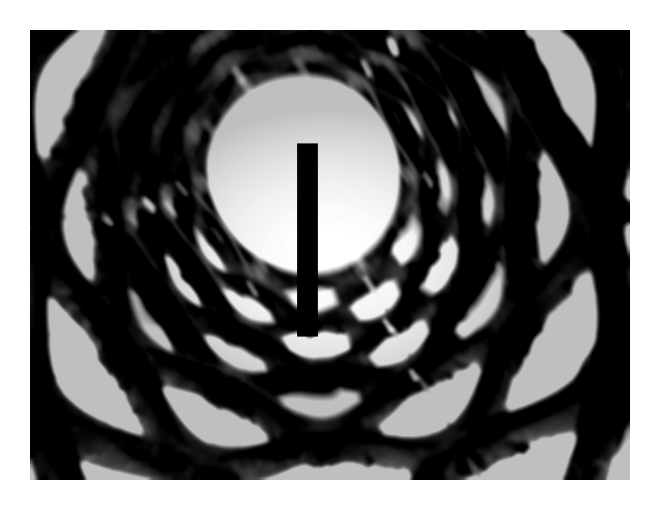

In [11]:
# pick 4 random images and apply the augmentations
paths = sorted(glob.glob("images/train/*.pt"))
N_PATHS = 8

dataset = ImageRegressionDataset(paths, paths, split="train")  # dummy labels

for i in range(N_PATHS):
    idx = random.randrange(len(dataset))
    image, _ = dataset[idx]  # augmented image
    image = image.float() / 255.0

    fig, ax = plt.subplots(1, 1, figsize=(2, 2))
    ax.imshow(image.squeeze(0).cpu(), cmap="gray", aspect="equal")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
    plt.show()


## 😓 Training of pose estimator

In [8]:
# Model for denormalization
class DenormalizedModel(nn.Module):
    def __init__(self, base_model, mean, std):
        super().__init__()
        self.base_model = base_model
        self.register_buffer("mean", mean)
        self.register_buffer("std", std)

    def forward(self, x):
        out = self.base_model(x)
        return out * self.std + self.mean
    
# Model for grayscale images CNN regression
class NetCameraBW(nn.Module):
    def __init__(self):
        super().__init__()

        # Load MobileNetV2 backbone
        mobilenet = models.mobilenet_v2(pretrained=True)

        # Adapt first conv layer to 1 input channel
        first_conv = mobilenet.features[0][0]
        mobilenet.features[0][0] = nn.Conv2d(
            in_channels=1,
            out_channels=first_conv.out_channels,
            kernel_size=first_conv.kernel_size,
            stride=first_conv.stride,
            padding=first_conv.padding,
            bias=False
        )

        self.backbone = mobilenet.features  # Only feature extractor

        self.pool = nn.AdaptiveAvgPool2d(1)  # Final pooling to [B, C, 1, 1]

        # Head for 6 regression outputs
        self.head = nn.Sequential(
            nn.Flatten(),              # [B, C]
            nn.Linear(1280, 6)         # MobileNetV2 output channels = 1280
        )

    def forward(self, x):
        x = x / 255.0  # Normalize input from [0,255] to [0,1]

        x = self.backbone(x)
        x = self.pool(x)

        return self.head(x)


In [10]:
model = NetCameraBW().to(device)

# Check the number of parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=5e-6)

# Learning rate management
scheduler = LinearLR(optimizer, start_factor = 1e-3, end_factor = 1.0, total_iters = 10)
plateau_scheduler = ReduceLROnPlateau(optimizer, mode = 'min', factor = 0.5, patience=5, verbose=True)

best_val_loss = float('inf')
patience = 30
counter = 0

# Normalization parameters
stats = torch.load("label_stats.pt")
mean = stats['mean'].to(device)
std = stats['std'].to(device)

history_train = []
history_val = []

scaler = GradScaler(device='cuda')

accumulation_steps = max(1, len(train_loader_y) // 5)
optimizer.zero_grad()
epochs = 500

if True:
    for epoch in range(epochs):
        model.train()
        train_losses = []
        total_batches = len(train_loader_y)

        for i, (images, labels) in enumerate(train_loader_y):
            images = images.to(device)
            labels = labels.to(device)

            with autocast(device_type='cuda'):
                labels_norm = (labels - mean) / std
                preds = model(images)
                loss = criterion(preds, labels_norm)

            loss = loss / accumulation_steps
            scaler.scale(loss).backward()

            train_losses.append(loss.item() * accumulation_steps)

            progress = (i + 1) / total_batches * 100
            sys.stdout.write(f"\rEpoch {epoch + 1}: {progress:.1f}%")
            sys.stdout.flush()

            # Perform gradient update at the end of the accumulation steps
            if (i + 1) % accumulation_steps == 0 or (i + 1) == total_batches:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

        model.eval()
        val_losses = []

        with torch.no_grad():
            for images, labels in val_loader_y:
                images = images.to(device)
                labels = labels.to(device)

                with autocast(device_type='cuda'):
                    labels_norm = (labels - mean) / std
                    preds = model(images)
                    loss = criterion(preds, labels_norm)

                val_losses.append(loss.item())

        avg_train_loss = np.mean(train_losses)
        avg_val_loss = np.mean(val_losses)
        scheduler.step()

        plateau_scheduler.step(avg_val_loss)
        history_train.append(avg_train_loss)
        history_val.append(avg_val_loss)

        sys.stdout.write("\r")
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch + 1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {current_lr:.6f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model, "models/vision/helyx_model_normalized.pt")
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print("Early stopping triggered.")
                break

    # Save training history
    history_single = {
        'train': history_train,
        'val': history_val
    }
    np.save('history_single.npy', history_single)

    del model
    del stats
    del mean
    del std
    del optimizer
    del scheduler
    del plateau_scheduler
    del scaler
    del history_train
    del history_val

# Load the best model and stats for denormalization
model = torch.load("models/vision/helyx_model_normalized.pt")
stats = torch.load("label_stats.pt")

# Move to device
model = model.to(device)
mean = stats['mean'].to(device)
std = stats['std'].to(device)

# Construction and serialization (.jit)
final_model = DenormalizedModel(model, mean, std)
scripted_model = torch.jit.script(final_model)
scripted_model.save("models/vision/helyx_model.pt")  # <-- standalone model

# Cleanup
del final_model, scripted_model, stats

Total trainable parameters: 2,230,982
Epoch 1 | Train Loss: 1.0996 | Val Loss: 1.1978 | LR: 0.000101
Epoch 2 | Train Loss: 0.9967 | Val Loss: 0.9912 | LR: 0.000201
Epoch 3 | Train Loss: 0.7632 | Val Loss: 0.4923 | LR: 0.000301
Epoch 4 | Train Loss: 0.4358 | Val Loss: 0.3653 | LR: 0.000401
Epoch 5 | Train Loss: 0.2899 | Val Loss: 0.1971 | LR: 0.000501
Epoch 6 | Train Loss: 0.2055 | Val Loss: 0.1408 | LR: 0.000600
Epoch 7 | Train Loss: 0.1655 | Val Loss: 0.1473 | LR: 0.000700
Epoch 8 | Train Loss: 0.1430 | Val Loss: 0.1331 | LR: 0.000800
Epoch 9 | Train Loss: 0.1269 | Val Loss: 0.1035 | LR: 0.000900
Epoch 10 | Train Loss: 0.1185 | Val Loss: 0.0847 | LR: 0.001000
Epoch 11 | Train Loss: 0.1128 | Val Loss: 0.0972 | LR: 0.001000
Epoch 12 | Train Loss: 0.1106 | Val Loss: 0.0755 | LR: 0.001000
Epoch 13 | Train Loss: 0.0997 | Val Loss: 0.0787 | LR: 0.001000
Epoch 14 | Train Loss: 0.0930 | Val Loss: 0.0810 | LR: 0.001000
Epoch 15 | Train Loss: 0.0892 | Val Loss: 0.0825 | LR: 0.001000
Epoch 16 | 

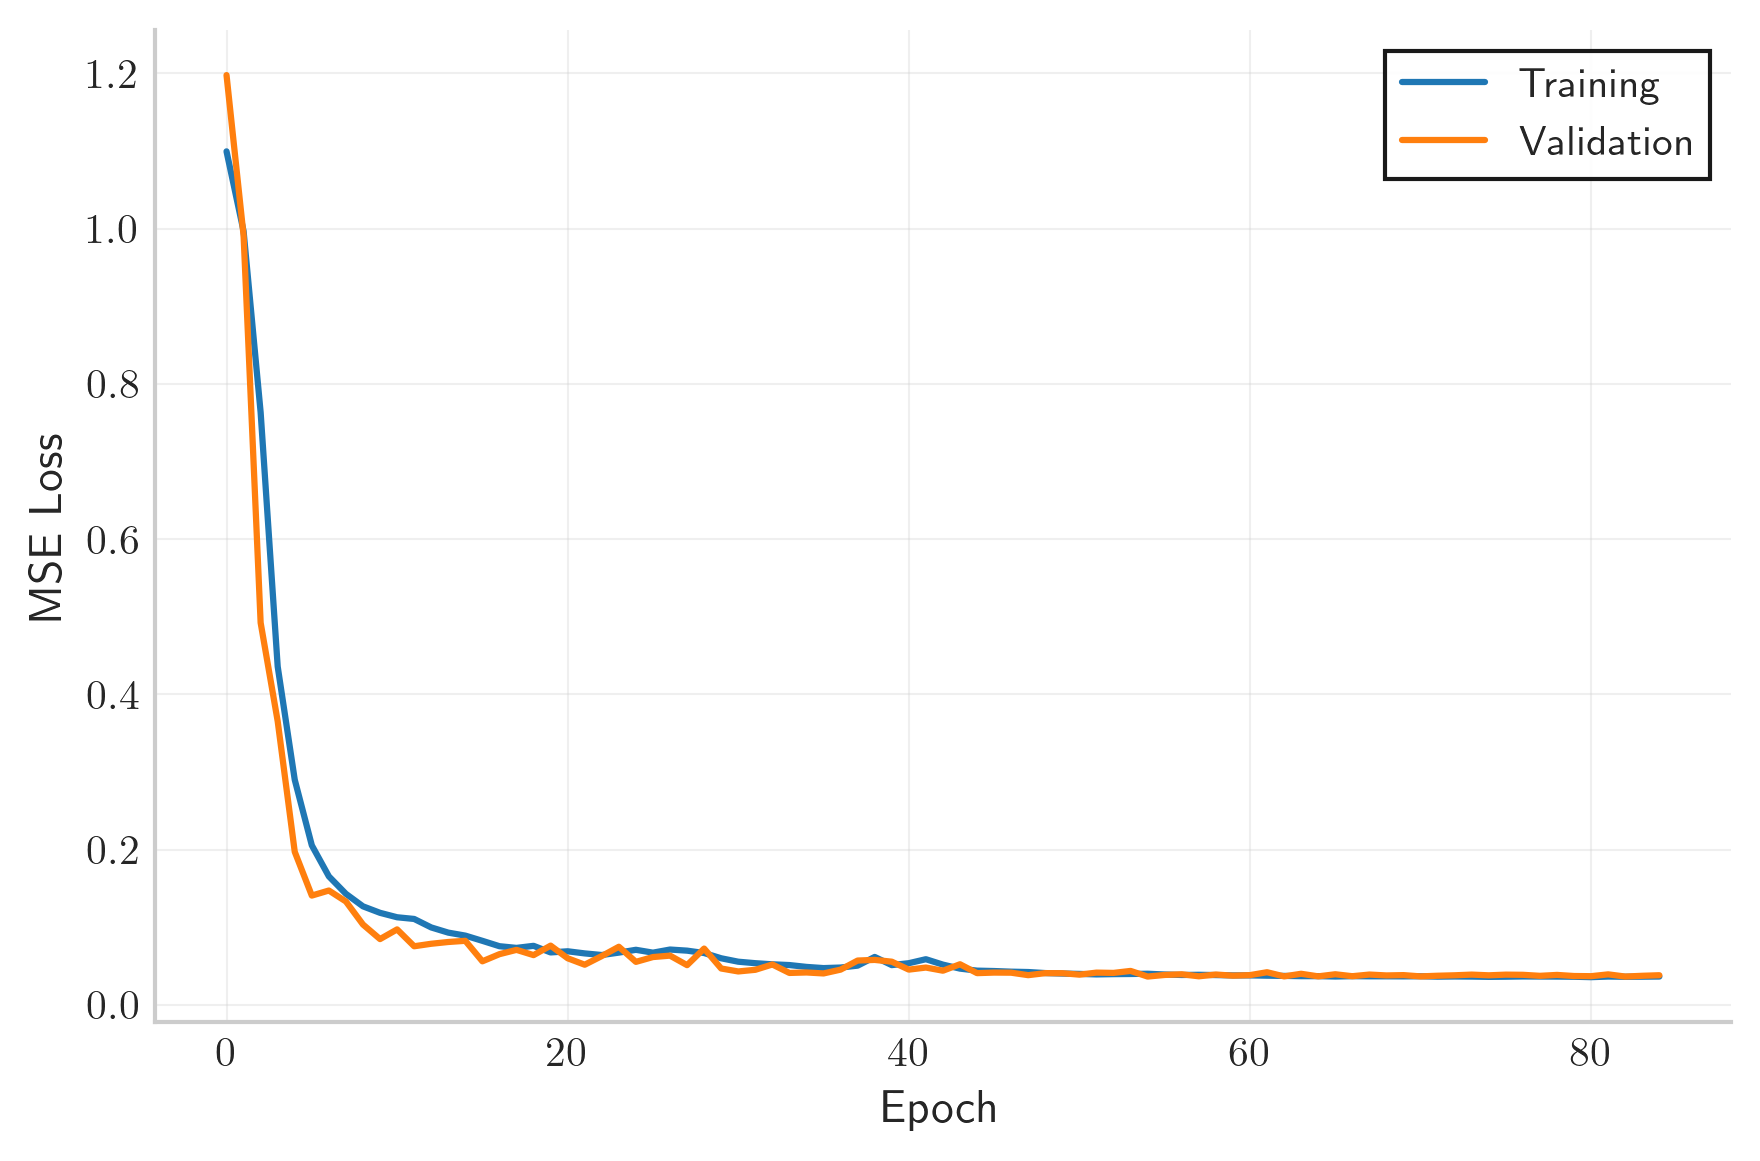

In [9]:
# Load history from file
history_single = np.load('history_single.npy', allow_pickle=True).item()
history_train = history_single['train']
history_val = history_single['val']

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(history_train, label='Training', linewidth=1.5)
ax.plot(history_val, label='Validation', linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
ax.tick_params(which='both', direction='in')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 😓 Training of reconstructor

In [12]:
# Redefine the model for denormalization, as all need the normalized one for transfer learning
class DenormalizedModel(nn.Module):
    def __init__(self, base_model, mean, std):
        super().__init__()
        self.base_model = base_model
        self.register_buffer("mean", mean)
        self.register_buffer("std", std)

    def forward(self, x):
        out = self.base_model(x)
        return out * self.std + self.mean

Quadratic curvature model

In [13]:
# Load wrapped model (DenormalizedModel)
wrapped_model = torch.load("models/vision/helyx_model_normalized.pt", map_location=device)

# Create a new NetCameraBW instance
model_new = NetCameraBW()

# Load weights
model_new.load_state_dict(wrapped_model.state_dict(), strict=False)

# Replace regression head with new one (i.e. for 5 outputs: S, c0, c1, c2, phi)
model_new.head = nn.Sequential(
    nn.Flatten(),
    nn.Linear(1280, 5)
)

model_new = model_new.to(device)

# Loss, optimizer, schedulers
criterion = nn.MSELoss()
optimizer = optim.Adam(model_new.parameters(), lr=1e-3, weight_decay=5e-6)
scheduler = LinearLR(optimizer, start_factor=1e-3, end_factor=1.0, total_iters=10)
plateau_scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)

# Normalization
stats = torch.load("quad_stats.pt")
mean = stats['mean'].to(device)
std = stats['std'].to(device)

best_val_loss = float('inf')
patience = 30
counter = 0
history_train = []
history_val = []

scaler = GradScaler(device='cuda')
accumulation_steps = max(1, len(loaders["quad"]["train"]) // 5)
optimizer.zero_grad()
epochs = 500

if True:
    for epoch in range(epochs):
        model_new.train()
        train_losses = []
        total_batches = len(loaders["quad"]["train"])

        for i, (images, labels) in enumerate(loaders["quad"]["train"]):
            images = images.to(device)
            labels = labels.to(device)

            with autocast(device_type='cuda'):
                # Labels
                labels_non_angle = (labels[:, :-1] - mean[:-1]) / std[:-1]
                phi_true = labels[:, -1]
                labels_ext = torch.cat((labels_non_angle,
                            torch.sin(phi_true).unsqueeze(1),
                            torch.cos(phi_true).unsqueeze(1)), dim=1)

                # Predictions
                preds_raw = model_new(images)
                preds_non_angle = preds_raw[:, :-1]
                phi_pred = preds_raw[:, -1]
                preds_ext = torch.cat((preds_non_angle,
                        torch.sin(phi_pred).unsqueeze(1),
                        torch.cos(phi_pred).unsqueeze(1)), dim=1)
                
                loss = criterion(preds_ext, labels_ext)

            # Scale loss for accumulation
            loss = loss / accumulation_steps
            scaler.scale(loss).backward()
            train_losses.append(loss.item() * accumulation_steps)

            progress = (i + 1) / total_batches * 100
            sys.stdout.write(f"\rEpoch {epoch + 1}: {progress:.1f}%")
            sys.stdout.flush()

            if (i + 1) % accumulation_steps == 0 or (i + 1) == total_batches:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

        model_new.eval()
        val_losses = []
        with torch.no_grad():
            for images, labels in loaders["quad"]["val"]:
                images = images.to(device)
                labels = labels.to(device)

                with autocast(device_type='cuda'):
                    # Labels
                    labels_non_angle = (labels[:, :-1] - mean[:-1]) / std[:-1]
                    phi_true = labels[:, -1]
                    labels_ext = torch.cat((labels_non_angle,
                            torch.sin(phi_true).unsqueeze(1),
                            torch.cos(phi_true).unsqueeze(1)), dim=1)

                    # Predictions
                    preds_raw = model_new(images)
                    preds_non_angle = preds_raw[:, :-1]
                    phi_pred = preds_raw[:, -1]
                    preds_ext = torch.cat((preds_non_angle,
                        torch.sin(phi_pred).unsqueeze(1),
                        torch.cos(phi_pred).unsqueeze(1)), dim=1)
                    
                    loss = criterion(preds_ext, labels_ext)
                    
                val_losses.append(loss.item())

        avg_train_loss = np.mean(train_losses)
        avg_val_loss = np.mean(val_losses)
        scheduler.step()
        plateau_scheduler.step(avg_val_loss)
        history_train.append(avg_train_loss)
        history_val.append(avg_val_loss)

        sys.stdout.write("\r")
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch + 1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {current_lr:.6f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model_new, "helyx_quad_curvature_normalized.pt")
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print("Early stopping triggered.")
                break

    # Save training history
    history_single = {
        'train': history_train,
        'val': history_val
    }
    np.save('history_single_quadratic.npy', history_single)

    # Cleanup
    del model_new, stats, mean, std
    del optimizer, scheduler, plateau_scheduler, scaler
    del history_train, history_val

# Model denormalization
model = torch.load("helyx_quad_curvature_normalized.pt")
stats = torch.load("quad_stats.pt")

# Move to device
model = model.to(device)
mean = stats['mean'].to(device)
std = stats['std'].to(device)

# Override mean and std for φ (last element)
mean[-1] = 0.0
std[-1] = 1.0

final_model = DenormalizedModel(model, mean, std)
scripted_model = torch.jit.script(final_model)
scripted_model.save("models/curvature/quadratic_model.pt")  # <-- standalone model

# Cleanup
del final_model, scripted_model, stats

Epoch 1 | Train Loss: 0.9345 | Val Loss: 0.9119 | LR: 0.000101
Epoch 2 | Train Loss: 0.8400 | Val Loss: 0.6524 | LR: 0.000201
Epoch 3 | Train Loss: 0.5309 | Val Loss: 0.3817 | LR: 0.000301
Epoch 4 | Train Loss: 0.3506 | Val Loss: 0.2597 | LR: 0.000401
Epoch 5 | Train Loss: 0.2794 | Val Loss: 0.2365 | LR: 0.000501
Epoch 6 | Train Loss: 0.2382 | Val Loss: 0.1965 | LR: 0.000600
Epoch 7 | Train Loss: 0.2083 | Val Loss: 0.2010 | LR: 0.000700
Epoch 8 | Train Loss: 0.1952 | Val Loss: 0.1912 | LR: 0.000800
Epoch 9 | Train Loss: 0.1842 | Val Loss: 0.1830 | LR: 0.000900
Epoch 10 | Train Loss: 0.1916 | Val Loss: 0.1959 | LR: 0.001000
Epoch 11 | Train Loss: 0.1886 | Val Loss: 0.1684 | LR: 0.001000
Epoch 12 | Train Loss: 0.1799 | Val Loss: 0.1615 | LR: 0.001000
Epoch 13 | Train Loss: 0.1670 | Val Loss: 0.1576 | LR: 0.001000
Epoch 14 | Train Loss: 0.1613 | Val Loss: 0.1608 | LR: 0.001000
Epoch 15 | Train Loss: 0.1657 | Val Loss: 0.1763 | LR: 0.001000
Epoch 16 | Train Loss: 0.1589 | Val Loss: 0.1807 

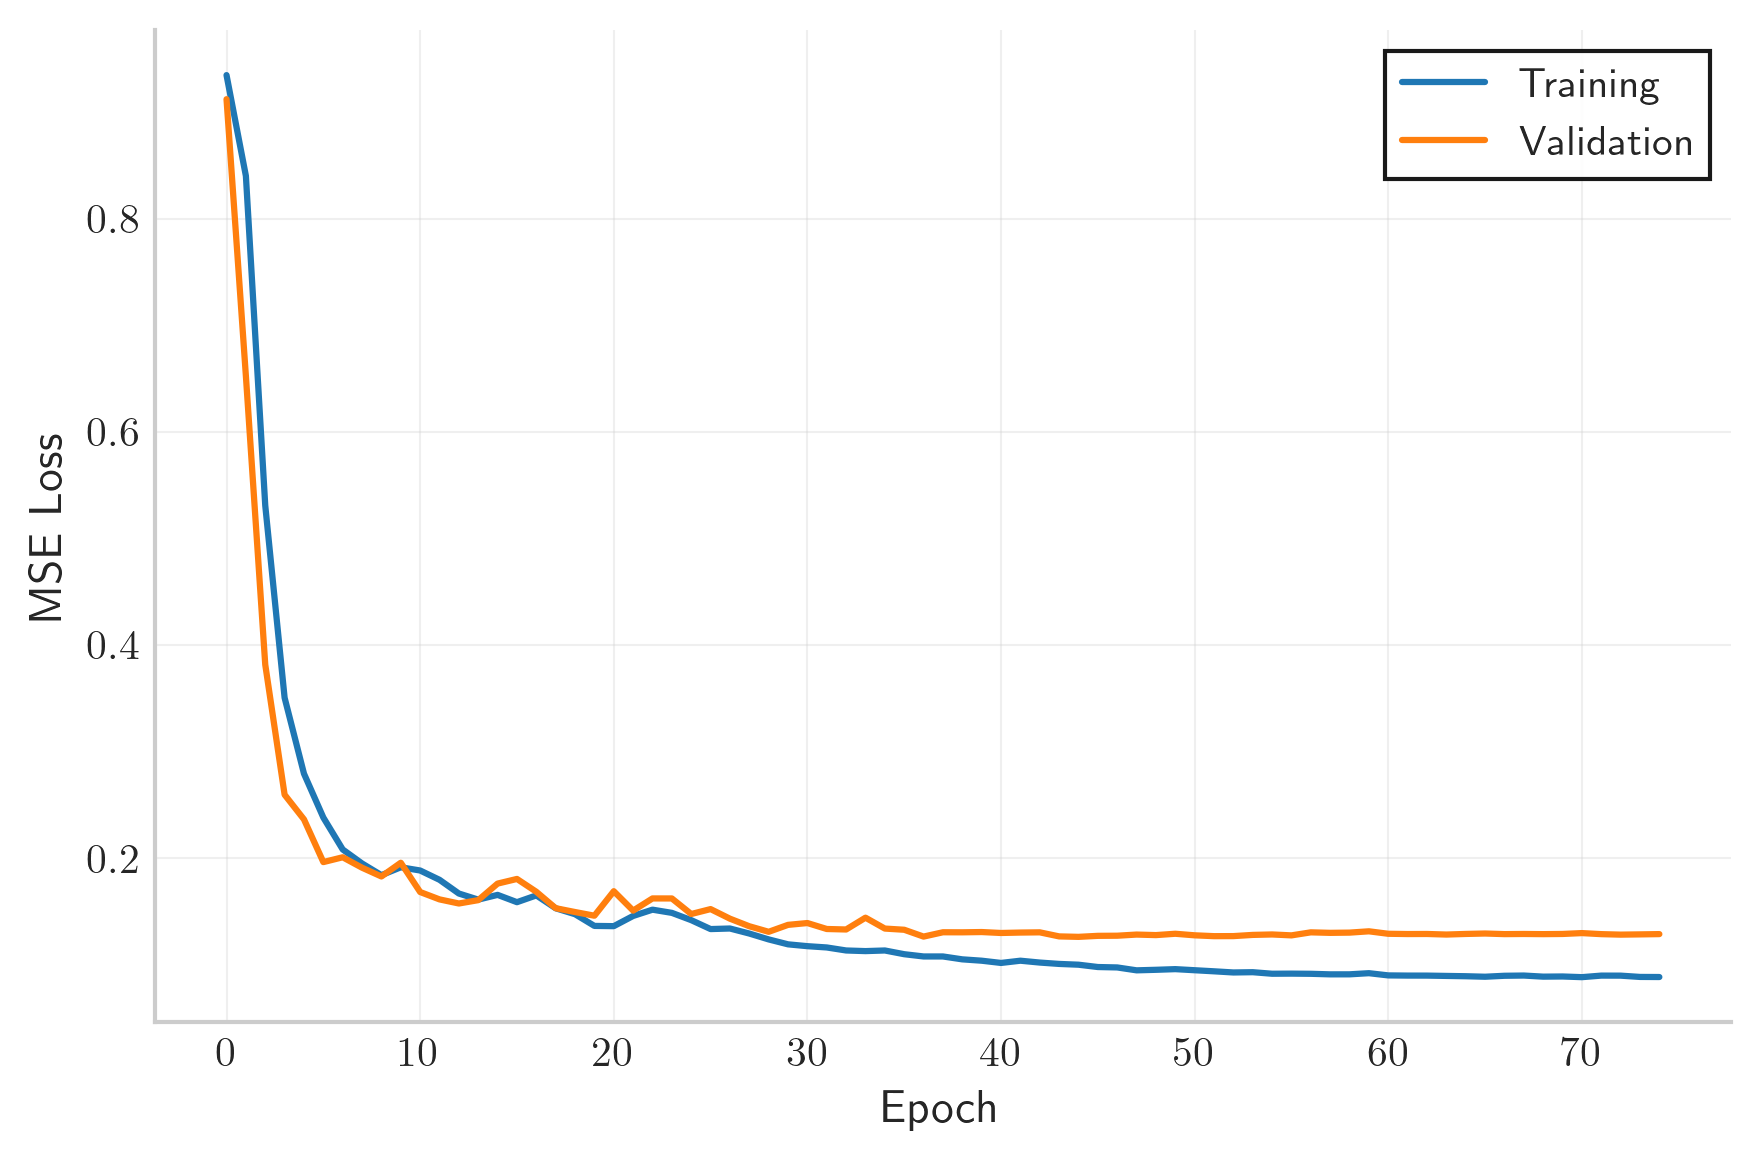

In [10]:
# Load history from file
history_single = np.load('history_single_quadratic.npy', allow_pickle=True).item()
history_train = history_single['train']
history_val = history_single['val']

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(history_train, label='Training', linewidth=1.5)
ax.plot(history_val, label='Validation', linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
ax.tick_params(which='both', direction='in')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Affine curvature model

In [15]:
# Load wrapped model (DenormalizedModel)
wrapped_model = torch.load("models/vision/helyx_model_normalized.pt", map_location=device)

# Create a new NetCameraBW instance
model_new = NetCameraBW()

# Load weights
model_new.load_state_dict(wrapped_model.state_dict(), strict=False)

# Replace regression head with new one (i.e. for 4 outputs: S, c0, c1, phi)
model_new.head = nn.Sequential(
    nn.Flatten(),
    nn.Linear(1280, 4)
)

model_new = model_new.to(device)

# Loss, optimizer, schedulers
criterion = nn.MSELoss()
optimizer = optim.Adam(model_new.parameters(), lr=1e-3, weight_decay=5e-6)
scheduler = LinearLR(optimizer, start_factor=1e-3, end_factor=1.0, total_iters=10)
plateau_scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)

# Normalization
stats = torch.load("affine_stats.pt")
mean = stats['mean'].to(device)
std = stats['std'].to(device)

best_val_loss = float('inf')
patience = 30
counter = 0
history_train = []
history_val = []

scaler = GradScaler(device='cuda')
accumulation_steps = max(1, len(loaders["affine"]["train"]) // 5)
optimizer.zero_grad()
epochs = 500

if True:
    for epoch in range(epochs):
        model_new.train()
        train_losses = []
        total_batches = len(loaders["affine"]["train"])

        for i, (images, labels) in enumerate(loaders["affine"]["train"]):
            images = images.to(device)
            labels = labels.to(device)

            with autocast(device_type='cuda'):
                # Labels
                labels_non_angle = (labels[:, :-1] - mean[:-1]) / std[:-1]
                phi_true = labels[:, -1]
                labels_ext = torch.cat((labels_non_angle,
                            torch.sin(phi_true).unsqueeze(1),
                            torch.cos(phi_true).unsqueeze(1)), dim=1)

                # Predictions
                preds_raw = model_new(images)
                preds_non_angle = preds_raw[:, :-1]
                phi_pred = preds_raw[:, -1]
                preds_ext = torch.cat((preds_non_angle,
                        torch.sin(phi_pred).unsqueeze(1),
                        torch.cos(phi_pred).unsqueeze(1)), dim=1)
                
                loss = criterion(preds_ext, labels_ext)

            loss = loss / accumulation_steps
            scaler.scale(loss).backward()
            train_losses.append(loss.item() * accumulation_steps)

            progress = (i + 1) / total_batches * 100
            sys.stdout.write(f"\rEpoch {epoch + 1}: {progress:.1f}%")
            sys.stdout.flush()

            if (i + 1) % accumulation_steps == 0 or (i + 1) == total_batches:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

        model_new.eval()
        val_losses = []
        with torch.no_grad():
            for images, labels in loaders["affine"]["val"]:
                images = images.to(device)
                labels = labels.to(device)

                with autocast(device_type='cuda'):
                    # Labels
                    labels_non_angle = (labels[:, :-1] - mean[:-1]) / std[:-1]
                    phi_true = labels[:, -1]
                    labels_ext = torch.cat((labels_non_angle,
                            torch.sin(phi_true).unsqueeze(1),
                            torch.cos(phi_true).unsqueeze(1)), dim=1)

                    # Predictions
                    preds_raw = model_new(images)
                    preds_non_angle = preds_raw[:, :-1]
                    phi_pred = preds_raw[:, -1]
                    preds_ext = torch.cat((preds_non_angle,
                        torch.sin(phi_pred).unsqueeze(1),
                        torch.cos(phi_pred).unsqueeze(1)), dim=1)
                    
                    loss = criterion(preds_ext, labels_ext)

                val_losses.append(loss.item())

        avg_train_loss = np.mean(train_losses)
        avg_val_loss = np.mean(val_losses)
        scheduler.step()
        plateau_scheduler.step(avg_val_loss)
        history_train.append(avg_train_loss)
        history_val.append(avg_val_loss)

        sys.stdout.write("\r")
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch + 1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {current_lr:.6f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model_new, "helyx_affine_curvature_normalized.pt")
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print("Early stopping triggered.")
                break

    # Save training history
    history_single = {
        'train': history_train,
        'val': history_val
    }
    np.save('history_single_affine.npy', history_single)

    # Cleanup
    del model_new, stats, mean, std
    del optimizer, scheduler, plateau_scheduler, scaler
    del history_train, history_val

# Model denormalization
model = torch.load("helyx_affine_curvature_normalized.pt")
stats = torch.load("affine_stats.pt")

# Move to device
model = model.to(device)
mean = stats['mean'].to(device)
std = stats['std'].to(device)

# Override mean and std for φ (last element)
mean[-1] = 0.0
std[-1] = 1.0

final_model = DenormalizedModel(model, mean, std)
scripted_model = torch.jit.script(final_model)
scripted_model.save("models/curvature/affine_model.pt")  # <-- standalone model

# Cleanup
del final_model, scripted_model, stats

Epoch 1 | Train Loss: 0.9679 | Val Loss: 0.9477 | LR: 0.000101
Epoch 2 | Train Loss: 0.8676 | Val Loss: 0.6894 | LR: 0.000201
Epoch 3 | Train Loss: 0.5571 | Val Loss: 0.3249 | LR: 0.000301
Epoch 4 | Train Loss: 0.3154 | Val Loss: 0.2618 | LR: 0.000401
Epoch 5 | Train Loss: 0.2584 | Val Loss: 0.1823 | LR: 0.000501
Epoch 6 | Train Loss: 0.2196 | Val Loss: 0.1661 | LR: 0.000600
Epoch 7 | Train Loss: 0.2018 | Val Loss: 0.1685 | LR: 0.000700
Epoch 8 | Train Loss: 0.1893 | Val Loss: 0.1371 | LR: 0.000800
Epoch 9 | Train Loss: 0.1733 | Val Loss: 0.1583 | LR: 0.000900
Epoch 10 | Train Loss: 0.1603 | Val Loss: 0.1555 | LR: 0.001000
Epoch 11 | Train Loss: 0.1591 | Val Loss: 0.1538 | LR: 0.001000
Epoch 12 | Train Loss: 0.1651 | Val Loss: 0.1410 | LR: 0.001000
Epoch 13 | Train Loss: 0.1573 | Val Loss: 0.1681 | LR: 0.001000
Epoch 14 | Train Loss: 0.1508 | Val Loss: 0.1619 | LR: 0.000500
Epoch 15 | Train Loss: 0.1531 | Val Loss: 0.1332 | LR: 0.000500
Epoch 16 | Train Loss: 0.1490 | Val Loss: 0.1265 

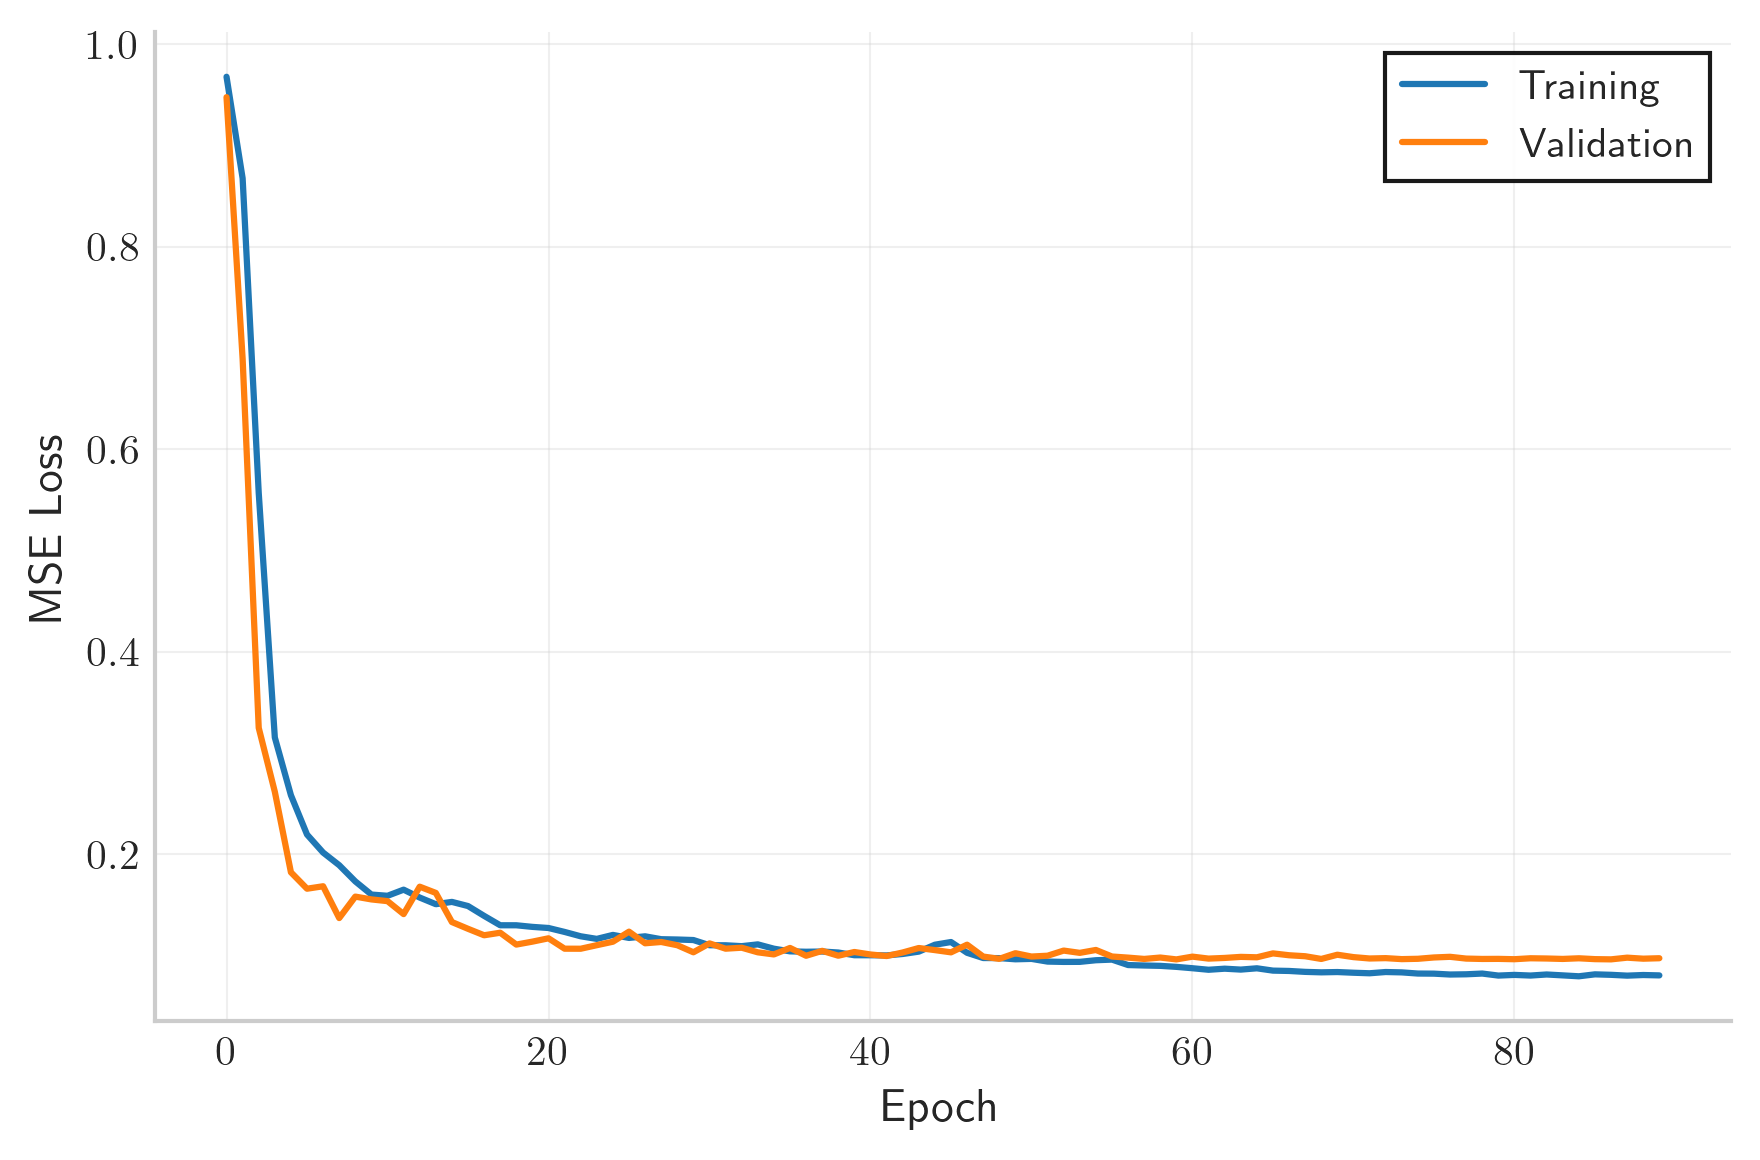

In [11]:
# Load history from file
history_single = np.load('history_single_affine.npy', allow_pickle=True).item()
history_train = history_single['train']
history_val = history_single['val']

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(history_train, label='Training', linewidth=1.5)
ax.plot(history_val, label='Validation', linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
ax.tick_params(which='both', direction='in')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Constant curvature model

In [17]:
# Load wrapped model (DenormalizedModel)
wrapped_model = torch.load("models/vision/helyx_model_normalized.pt", map_location=device)

# Create a new NetCameraBW instance
model_new = NetCameraBW()

# Load weights
model_new.load_state_dict(wrapped_model.state_dict(), strict=False)

# Replace regression head with new one (i.e. for 3 outputs: S, c0, phi)
model_new.head = nn.Sequential(
    nn.Flatten(),
    nn.Linear(1280, 3)
)

model_new = model_new.to(device)

# Loss, optimizer, schedulers
criterion = nn.MSELoss()
optimizer = optim.Adam(model_new.parameters(), lr=1e-3, weight_decay=5e-6)
scheduler = LinearLR(optimizer, start_factor=1e-3, end_factor=1.0, total_iters=10)
plateau_scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)

# Normalization
stats = torch.load("const_stats.pt")
mean = stats['mean'].to(device)
std = stats['std'].to(device)

best_val_loss = float('inf')
patience = 30
counter = 0
history_train = []
history_val = []

scaler = GradScaler(device='cuda')
accumulation_steps = max(1, len(loaders["const"]["train"]) // 5)
optimizer.zero_grad()
epochs = 500

if True:
    for epoch in range(epochs):
        model_new.train()
        train_losses = []
        total_batches = len(loaders["const"]["train"])

        for i, (images, labels) in enumerate(loaders["const"]["train"]):
            images = images.to(device)
            labels = labels.to(device)

            with autocast(device_type='cuda'):
                # Labels
                labels_non_angle = (labels[:, :-1] - mean[:-1]) / std[:-1]
                phi_true = labels[:, -1]
                labels_ext = torch.cat((labels_non_angle,
                            torch.sin(phi_true).unsqueeze(1),
                            torch.cos(phi_true).unsqueeze(1)), dim=1)

                # Predictions
                preds_raw = model_new(images)
                preds_non_angle = preds_raw[:, :-1]
                phi_pred = preds_raw[:, -1]
                preds_ext = torch.cat((preds_non_angle,
                        torch.sin(phi_pred).unsqueeze(1),
                        torch.cos(phi_pred).unsqueeze(1)), dim=1)
                
                loss = criterion(preds_ext, labels_ext)

            loss = loss / accumulation_steps
            scaler.scale(loss).backward()
            train_losses.append(loss.item() * accumulation_steps)

            progress = (i + 1) / total_batches * 100
            sys.stdout.write(f"\rEpoch {epoch + 1}: {progress:.1f}%")
            sys.stdout.flush()

            if (i + 1) % accumulation_steps == 0 or (i + 1) == total_batches:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

        model_new.eval()
        val_losses = []
        with torch.no_grad():
            for images, labels in loaders["const"]["val"]:
                images = images.to(device)
                labels = labels.to(device)

                with autocast(device_type='cuda'):
                    # Labels
                    labels_non_angle = (labels[:, :-1] - mean[:-1]) / std[:-1]
                    phi_true = labels[:, -1]
                    labels_ext = torch.cat((labels_non_angle,
                            torch.sin(phi_true).unsqueeze(1),
                            torch.cos(phi_true).unsqueeze(1)), dim=1)

                    # Predictions
                    preds_raw = model_new(images)
                    preds_non_angle = preds_raw[:, :-1]
                    phi_pred = preds_raw[:, -1]
                    preds_ext = torch.cat((preds_non_angle,
                        torch.sin(phi_pred).unsqueeze(1),
                        torch.cos(phi_pred).unsqueeze(1)), dim=1)
                    
                    loss = criterion(preds_ext, labels_ext)

                val_losses.append(loss.item())

        avg_train_loss = np.mean(train_losses)
        avg_val_loss = np.mean(val_losses)
        scheduler.step()
        plateau_scheduler.step(avg_val_loss)
        history_train.append(avg_train_loss)
        history_val.append(avg_val_loss)

        sys.stdout.write("\r")
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch + 1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {current_lr:.6f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model_new, "helyx_const_curvature_normalized.pt")
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print("Early stopping triggered.")
                break

    # Save training history
    history_single = {
        'train': history_train,
        'val': history_val
    }
    np.save('history_single_const.npy', history_single)

    # Cleanup
    del model_new, stats, mean, std
    del optimizer, scheduler, plateau_scheduler, scaler
    del history_train, history_val

# Model denormalization
model = torch.load("helyx_const_curvature_normalized.pt")
stats = torch.load("const_stats.pt")

# Move to device
model = model.to(device)
mean = stats['mean'].to(device)
std = stats['std'].to(device)

# Override mean and std for φ (last element)
mean[-1] = 0.0
std[-1] = 1.0

final_model = DenormalizedModel(model, mean, std)
scripted_model = torch.jit.script(final_model)
scripted_model.save("models/curvature/const_model.pt")  # <-- standalone model

# Cleanup
del final_model, scripted_model, stats


Epoch 1 | Train Loss: 0.9668 | Val Loss: 0.9741 | LR: 0.000101
Epoch 2 | Train Loss: 0.8558 | Val Loss: 0.6757 | LR: 0.000201
Epoch 3 | Train Loss: 0.5273 | Val Loss: 0.2872 | LR: 0.000301
Epoch 4 | Train Loss: 0.2674 | Val Loss: 0.2210 | LR: 0.000401
Epoch 5 | Train Loss: 0.2033 | Val Loss: 0.1372 | LR: 0.000501
Epoch 6 | Train Loss: 0.1777 | Val Loss: 0.1179 | LR: 0.000600
Epoch 7 | Train Loss: 0.1564 | Val Loss: 0.1176 | LR: 0.000700
Epoch 8 | Train Loss: 0.1369 | Val Loss: 0.0941 | LR: 0.000800
Epoch 9 | Train Loss: 0.1341 | Val Loss: 0.1175 | LR: 0.000900
Epoch 10 | Train Loss: 0.1328 | Val Loss: 0.1163 | LR: 0.001000
Epoch 11 | Train Loss: 0.1319 | Val Loss: 0.1402 | LR: 0.001000
Epoch 12 | Train Loss: 0.1269 | Val Loss: 0.1237 | LR: 0.001000
Epoch 13 | Train Loss: 0.1183 | Val Loss: 0.1300 | LR: 0.001000
Epoch 14 | Train Loss: 0.1221 | Val Loss: 0.1105 | LR: 0.000500
Epoch 15 | Train Loss: 0.1229 | Val Loss: 0.0993 | LR: 0.000500
Epoch 16 | Train Loss: 0.1163 | Val Loss: 0.0948 

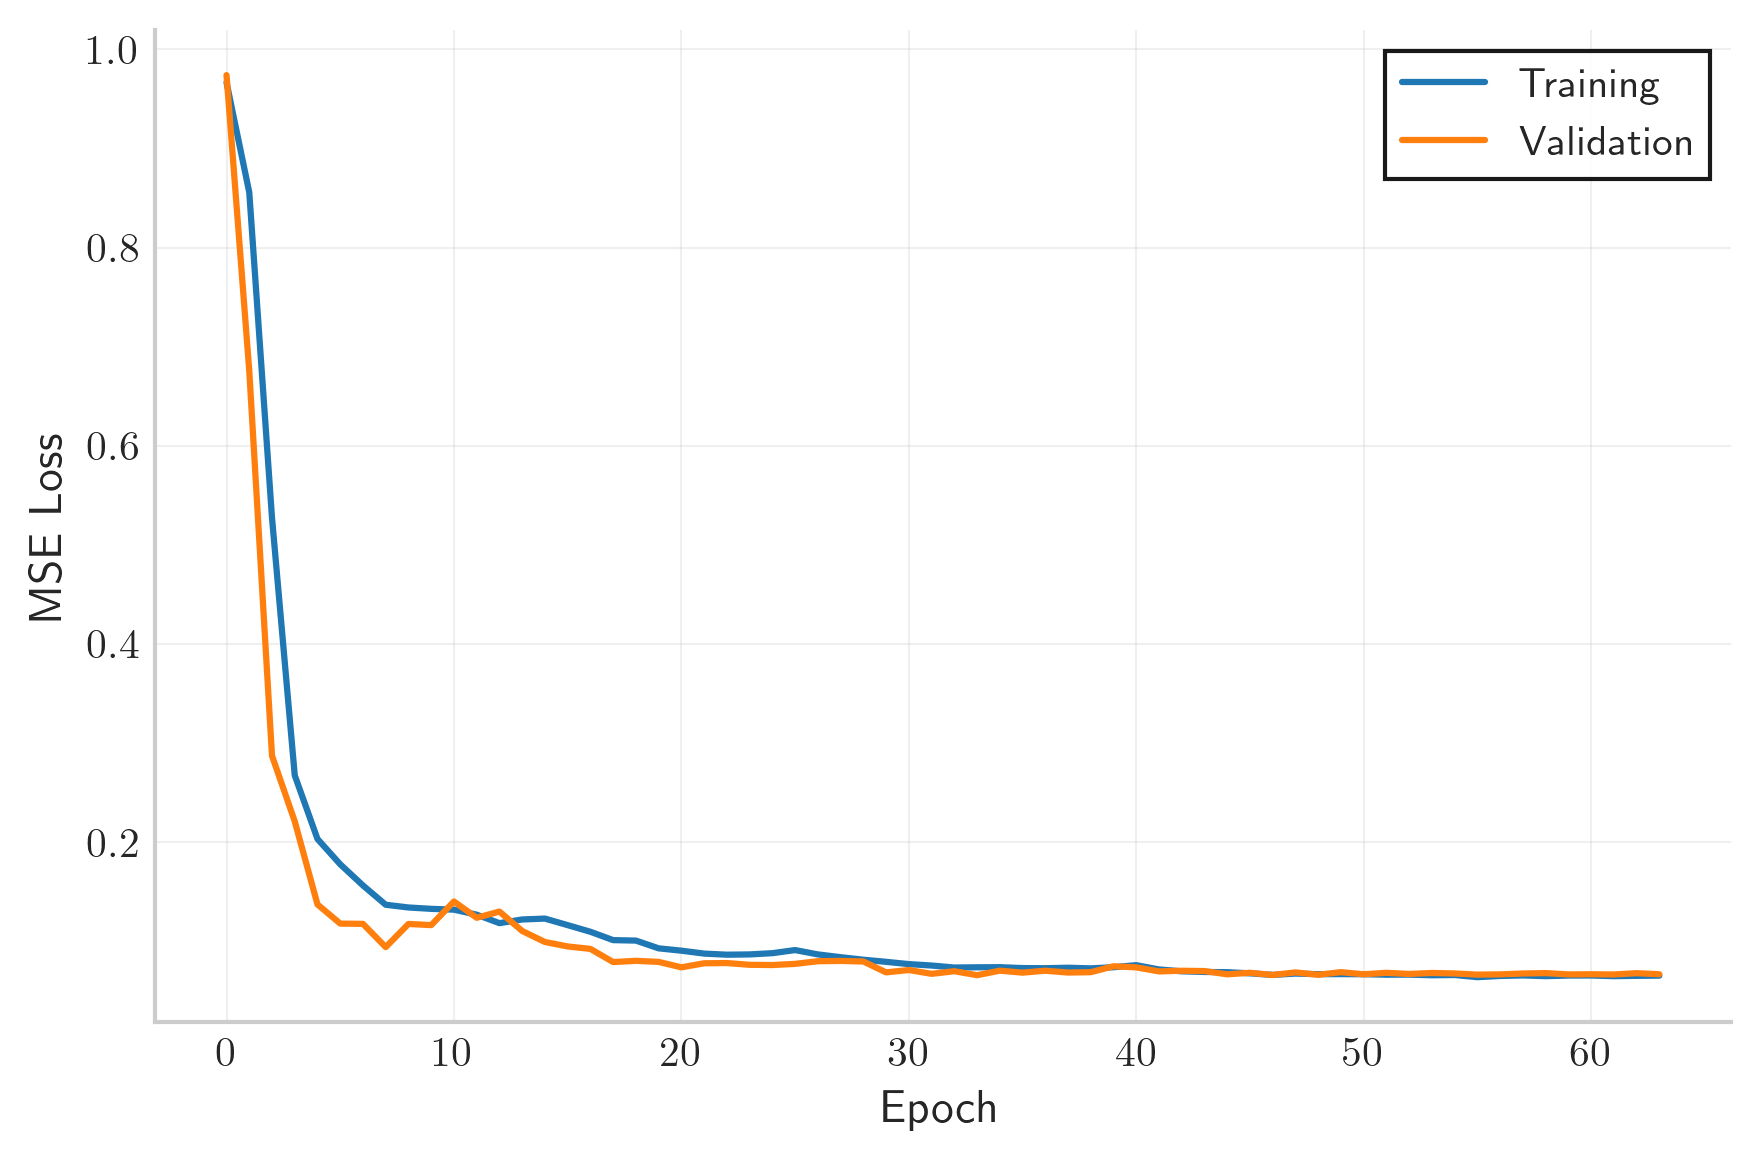

In [12]:
# Load history from file
history_single = np.load('history_single_const.npy', allow_pickle=True).item()
history_train = history_single['train']
history_val = history_single['val']

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(history_train, label='Training', linewidth=1.5)
ax.plot(history_val, label='Validation', linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
ax.tick_params(which='both', direction='in')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 😓 Training of Inverse Kinematics model

In [16]:
# Network definition, Residual Block to avoid vanishing gradients
class ResidualBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.linear1 = nn.Linear(dim, dim)
        self.bn1 = nn.BatchNorm1d(dim)
        self.linear2 = nn.Linear(dim, dim)
        self.bn2 = nn.BatchNorm1d(dim)
        self.activation = nn.LeakyReLU()

    def forward(self, x):
        residual = x
        out = self.linear1(x)
        out = self.bn1(out)
        out = self.activation(out)
        out = self.linear2(out)
        out = self.bn2(out)
        out = out + residual
        return self.activation(out)

class NetKinematics(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_layer = nn.Sequential(
            nn.Linear(3, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU()
        )

        self.residual_blocks = nn.Sequential(
            ResidualBlock(128),
            ResidualBlock(128),
            ResidualBlock(128)
        )

        self.output_layers = nn.Sequential(
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(),
            nn.Linear(32, 3)
        )

    def forward(self, x):
        x = self.input_layer(x)
        x = self.residual_blocks(x)
        x = self.output_layers(x)
        return x

# Recall DenormalizedModel class   
class DenormalizedModel(nn.Module):
    def __init__(self, base_model, mean, std):
        super().__init__()
        self.base_model = base_model
        self.register_buffer("mean", mean)
        self.register_buffer("std", std)

    def forward(self, x):
        out = self.base_model(x)
        return out * self.std + self.mean

In [20]:
model = NetKinematics().to(device)

# Check the number of parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

# Learning rate management
scheduler = LinearLR(optimizer, start_factor = 1e-3, end_factor = 1.0, total_iters = 10)
plateau_scheduler = ReduceLROnPlateau(optimizer, mode = 'min', factor = 0.5, patience=5, verbose=True)

best_val_loss = float('inf')
patience = 30
counter = 0

# Normalization parameters
stats = torch.load("deltal_stats.pt")
mean = stats['mean'].to(device)
std = stats['std'].to(device)

history_train = []
history_val = []

scaler = GradScaler(device=device)

accumulation_steps = max(1, len(train_loader_IK) // 10)
optimizer.zero_grad()
epochs = 500
best_val_loss = float("inf")

if True:
    for epoch in range(epochs):
        model.train()
        train_losses = []
        total_batches = len(train_loader_IK)

        for i, (inputs, targets) in enumerate(train_loader_IK):
            inputs = inputs.to(device)
            targets = targets.to(device)

            with autocast(device_type=device.type):
                targets_norm = (targets - mean) / std
                preds = model(inputs)
                loss = criterion(preds, targets_norm)

            loss = loss / accumulation_steps
            scaler.scale(loss).backward()
            train_losses.append(loss.item() * accumulation_steps)

            progress = (i + 1) / total_batches * 100
            sys.stdout.write(f"\rEpoch {epoch + 1}: {progress:.1f}%")
            sys.stdout.flush()

            if (i + 1) % accumulation_steps == 0 or (i + 1) == total_batches:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

        model.eval()
        val_losses = []

        with torch.no_grad():
            for inputs, targets in val_loader_IK:
                inputs = inputs.to(device)
                targets = targets.to(device)

                with autocast(device_type=device.type):
                    targets_norm = (targets - mean) / std
                    preds = model(inputs)
                    loss = criterion(preds, targets_norm)

                val_losses.append(loss.item())

        avg_train_loss = np.mean(train_losses)
        avg_val_loss = np.mean(val_losses)
        scheduler.step()
        plateau_scheduler.step(avg_val_loss)

        history_train.append(avg_train_loss)
        history_val.append(avg_val_loss)

        sys.stdout.write("\r")
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch + 1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {current_lr:.6f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model, "kinematics_normalized.pt")
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print("Early stopping triggered.")
                break

    # Save training history
    history_single = {
        'train': history_train,
        'val': history_val
    }
    np.save('history_single_kinematics.npy', history_single)

    # Clean-up
    del model, stats, mean, std, optimizer, scheduler, plateau_scheduler, scaler
    del history_train, history_val

model = torch.load("kinematics_normalized.pt")
stats = torch.load("deltal_stats.pt")

# Move to device
model = model.to(device)
mean = stats['mean'].to(device)
std = stats['std'].to(device)

# Construction and serialization (.jit)
final_model = DenormalizedModel(model, mean, std)
scripted_model = torch.jit.script(final_model)
scripted_model.save("models/kinematics/kinematics_model.pt")  # <-- standalone model

# Cleanup
del final_model, scripted_model, stats

Total trainable parameters: 112,003
Epoch 1 | Train Loss: 1.2541 | Val Loss: 1.2205 | LR: 0.000101
Epoch 2 | Train Loss: 0.8529 | Val Loss: 0.5040 | LR: 0.000201
Epoch 3 | Train Loss: 0.4091 | Val Loss: 0.2681 | LR: 0.000301
Epoch 4 | Train Loss: 0.2435 | Val Loss: 0.1700 | LR: 0.000401
Epoch 5 | Train Loss: 0.1555 | Val Loss: 0.1002 | LR: 0.000501
Epoch 6 | Train Loss: 0.1093 | Val Loss: 0.0678 | LR: 0.000600
Epoch 7 | Train Loss: 0.0839 | Val Loss: 0.0473 | LR: 0.000700
Epoch 8 | Train Loss: 0.0691 | Val Loss: 0.0434 | LR: 0.000800
Epoch 9 | Train Loss: 0.0650 | Val Loss: 0.0376 | LR: 0.000900
Epoch 10 | Train Loss: 0.0588 | Val Loss: 0.0369 | LR: 0.001000
Epoch 11 | Train Loss: 0.0600 | Val Loss: 0.0375 | LR: 0.001000
Epoch 12 | Train Loss: 0.0563 | Val Loss: 0.0370 | LR: 0.001000
Epoch 13 | Train Loss: 0.0579 | Val Loss: 0.0392 | LR: 0.001000
Epoch 14 | Train Loss: 0.0569 | Val Loss: 0.0384 | LR: 0.001000
Epoch 15 | Train Loss: 0.0539 | Val Loss: 0.0362 | LR: 0.001000
Epoch 16 | Tr

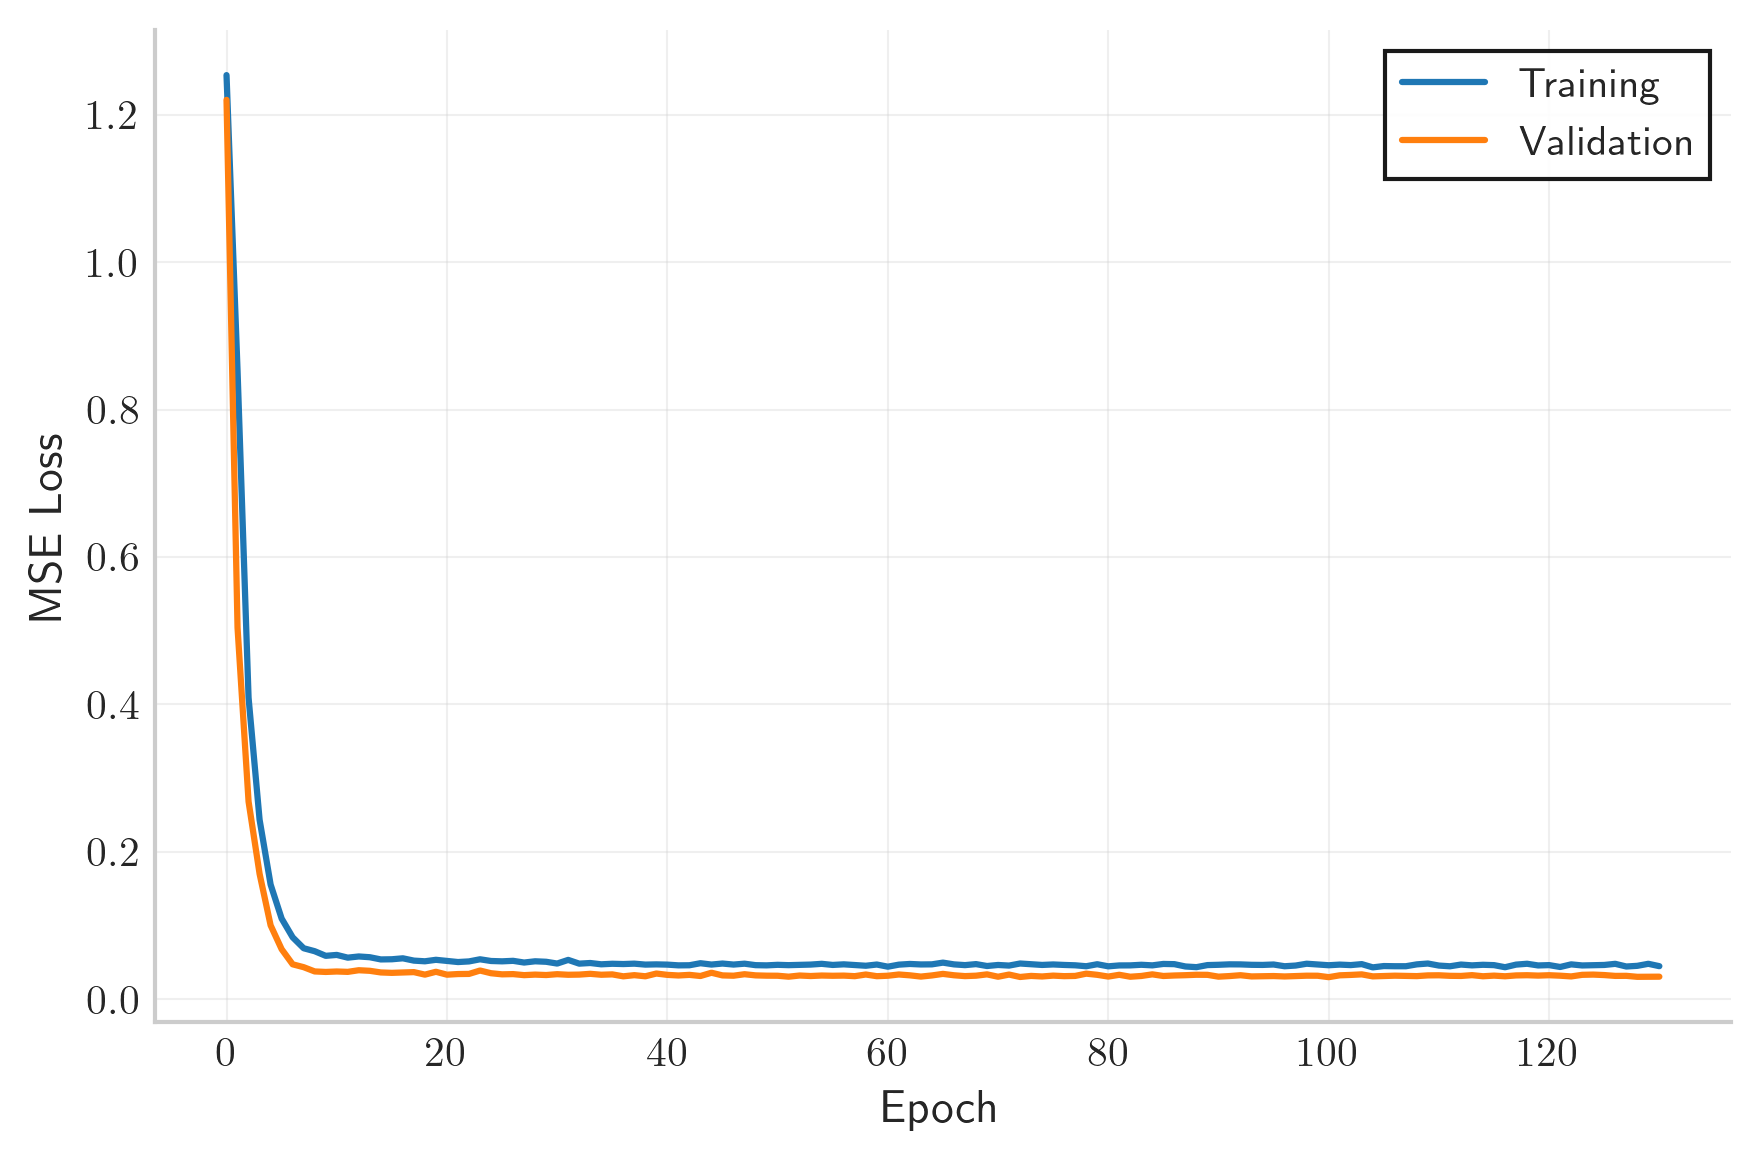

In [13]:
# Load history from file
history_single = np.load('history_single_kinematics.npy', allow_pickle=True).item()
history_train = history_single['train']
history_val = history_single['val']

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(history_train, label='Training', linewidth=1.5)
ax.plot(history_val, label='Validation', linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
ax.tick_params(which='both', direction='in')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 😓 Training of Curvature regressors for multisection

In [18]:
# Network definition, Residual Block to avoid vanishing gradients
class ResidualBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.linear1 = nn.Linear(dim, dim)
        self.bn1 = nn.BatchNorm1d(dim)
        self.linear2 = nn.Linear(dim, dim)
        self.bn2 = nn.BatchNorm1d(dim)
        self.activation = nn.LeakyReLU()

    def forward(self, x):
        residual = x
        out = self.linear1(x)
        out = self.bn1(out)
        out = self.activation(out)
        out = self.linear2(out)
        out = self.bn2(out)
        out = out + residual
        return self.activation(out)

class NetCurvature(nn.Module):
    def __init__(self, mode='quadratic'):
        super().__init__()

        # Avoid the prediction of s
        if mode == 'affine':
            self.output_dim = 4
        elif mode == 'constant':
            self.output_dim = 3
        else:
            self.output_dim = 5

        self.input_layer = nn.Sequential(
            nn.Linear(9, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU()
        )

        self.residual_blocks = nn.Sequential(
            ResidualBlock(128),
            ResidualBlock(128),
            ResidualBlock(128)
        )

        self.output_layer = nn.Sequential(
            nn.Linear(128, self.output_dim)
        )

    def forward(self, x):
        x = self.input_layer(x)
        x = self.residual_blocks(x)
        x = self.output_layer(x)
        return x


Quadratic

In [19]:
model = NetCurvature(mode='quadratic').to(device)

# Check the number of parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

# Learning rate management
scheduler = LinearLR(optimizer, start_factor = 1e-3, end_factor = 1.0, total_iters = 10)
plateau_scheduler = ReduceLROnPlateau(optimizer, mode = 'min', factor = 0.5, patience=5, verbose=True)

best_val_loss = float('inf')
patience = 30
counter = 0

# Normalization parameters
stats = torch.load("quad_stats.pt")
mean = stats['mean'].to(device)
std = stats['std'].to(device)

history_train = []
history_val = []

scaler = GradScaler(device=device)

accumulation_steps = max(1, len(train_loader_quad) // 10)
optimizer.zero_grad()
epochs = 500
best_val_loss = float("inf")

for epoch in range(epochs):
    model.train()
    train_losses = []
    total_batches = len(train_loader_quad)

    for i, (inputs, targets) in enumerate(train_loader_quad):
        inputs = inputs.to(device)
        targets = targets.to(device)

        with autocast(device_type=device.type):
            targets_norm = (targets - mean) / std
            preds = model(inputs)
            loss = criterion(preds, targets_norm)

        loss = loss / accumulation_steps
        scaler.scale(loss).backward()
        train_losses.append(loss.item() * accumulation_steps)

        progress = (i + 1) / total_batches * 100
        sys.stdout.write(f"\rEpoch {epoch + 1}: {progress:.1f}%")
        sys.stdout.flush()

        if (i + 1) % accumulation_steps == 0 or (i + 1) == total_batches:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

    model.eval()
    val_losses = []

    with torch.no_grad():
        for inputs, targets in val_loader_quad:
            inputs = inputs.to(device)
            targets = targets.to(device)

            with autocast(device_type=device.type):
                targets_norm = (targets - mean) / std
                preds = model(inputs)
                loss = criterion(preds, targets_norm)

            val_losses.append(loss.item())

    avg_train_loss = np.mean(train_losses)
    avg_val_loss = np.mean(val_losses)
    scheduler.step()
    plateau_scheduler.step(avg_val_loss)

    history_train.append(avg_train_loss)
    history_val.append(avg_val_loss)

    sys.stdout.write("\r")
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch + 1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {current_lr:.6f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model, "quadratic_for_MULTI_normalized.pt")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

# Clean-up
del model, stats, mean, std, optimizer, scheduler, plateau_scheduler, scaler

model = torch.load("quadratic_for_MULTI_normalized.pt")
stats = torch.load("quad_stats.pt")

# Move to device
model = model.to(device)
mean = stats['mean'].to(device)
std = stats['std'].to(device)

# Construction and serialization (.jit)
final_model = DenormalizedModel(model, mean, std)
scripted_model = torch.jit.script(final_model)
scripted_model.save("models/curvature/quadratic_for_MULTI_model.pt")  # <-- standalone model

# Cleanup
del final_model, scripted_model, stats

Total trainable parameters: 102,789
Epoch 1 | Train Loss: 2.5011 | Val Loss: 2.4480 | LR: 0.000101
Epoch 2 | Train Loss: 1.7296 | Val Loss: 0.9280 | LR: 0.000201
Epoch 3 | Train Loss: 0.6130 | Val Loss: 0.3161 | LR: 0.000301
Epoch 4 | Train Loss: 0.2719 | Val Loss: 0.1703 | LR: 0.000401
Epoch 5 | Train Loss: 0.2005 | Val Loss: 0.1443 | LR: 0.000501
Epoch 6 | Train Loss: 0.1652 | Val Loss: 0.1108 | LR: 0.000600
Epoch 7 | Train Loss: 0.1539 | Val Loss: 0.1028 | LR: 0.000700
Epoch 8 | Train Loss: 0.1417 | Val Loss: 0.1000 | LR: 0.000800
Epoch 9 | Train Loss: 0.1448 | Val Loss: 0.0933 | LR: 0.000900
Epoch 10 | Train Loss: 0.1410 | Val Loss: 0.0937 | LR: 0.001000
Epoch 11 | Train Loss: 0.1331 | Val Loss: 0.0959 | LR: 0.001000
Epoch 12 | Train Loss: 0.1317 | Val Loss: 0.0891 | LR: 0.001000
Epoch 13 | Train Loss: 0.1312 | Val Loss: 0.0886 | LR: 0.001000
Epoch 14 | Train Loss: 0.1256 | Val Loss: 0.0958 | LR: 0.001000
Epoch 15 | Train Loss: 0.1227 | Val Loss: 0.0881 | LR: 0.001000
Epoch 16 | Tr

Affine

In [20]:
model = NetCurvature(mode='affine').to(device)

# Check the number of parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

# Learning rate management
scheduler = LinearLR(optimizer, start_factor = 1e-3, end_factor = 1.0, total_iters = 10)
plateau_scheduler = ReduceLROnPlateau(optimizer, mode = 'min', factor = 0.5, patience=5, verbose=True)

best_val_loss = float('inf')
patience = 30
counter = 0

# Normalization parameters
stats = torch.load("affine_stats.pt")
mean = stats['mean'].to(device)
std = stats['std'].to(device)

history_train = []
history_val = []

scaler = GradScaler(device=device)

accumulation_steps = max(1, len(train_loader_IK) // 10)
optimizer.zero_grad()
epochs = 500
best_val_loss = float("inf")

for epoch in range(epochs):
    model.train()
    train_losses = []
    total_batches = len(train_loader_affine)

    for i, (inputs, targets) in enumerate(train_loader_affine):
        inputs = inputs.to(device)
        targets = targets.to(device)

        with autocast(device_type=device.type):
            targets_norm = (targets - mean) / std
            preds = model(inputs)
            loss = criterion(preds, targets_norm)

        loss = loss / accumulation_steps
        scaler.scale(loss).backward()
        train_losses.append(loss.item() * accumulation_steps)

        progress = (i + 1) / total_batches * 100
        sys.stdout.write(f"\rEpoch {epoch + 1}: {progress:.1f}%")
        sys.stdout.flush()

        if (i + 1) % accumulation_steps == 0 or (i + 1) == total_batches:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

    model.eval()
    val_losses = []

    with torch.no_grad():
        for inputs, targets in val_loader_affine:
            inputs = inputs.to(device)
            targets = targets.to(device)

            with autocast(device_type=device.type):
                targets_norm = (targets - mean) / std
                preds = model(inputs)
                loss = criterion(preds, targets_norm)

            val_losses.append(loss.item())

    avg_train_loss = np.mean(train_losses)
    avg_val_loss = np.mean(val_losses)
    scheduler.step()
    plateau_scheduler.step(avg_val_loss)

    history_train.append(avg_train_loss)
    history_val.append(avg_val_loss)

    sys.stdout.write("\r")
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch + 1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {current_lr:.6f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model, "affine_for_MULTI_normalized.pt")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

# Clean-up
del model, stats, mean, std, optimizer, scheduler, plateau_scheduler, scaler

model = torch.load("affine_for_MULTI_normalized.pt")
stats = torch.load("affine_stats.pt")

# Move to device
model = model.to(device)
mean = stats['mean'].to(device)
std = stats['std'].to(device)

# Construction and serialization (.jit)
final_model = DenormalizedModel(model, mean, std)
scripted_model = torch.jit.script(final_model)
scripted_model.save("models/curvature/affine_for_MULTI_model.pt")  # <-- standalone model

# Cleanup
del final_model, scripted_model, stats

Total trainable parameters: 102,660
Epoch 1 | Train Loss: 2.0634 | Val Loss: 2.0353 | LR: 0.000101
Epoch 2 | Train Loss: 1.3257 | Val Loss: 0.7367 | LR: 0.000201
Epoch 3 | Train Loss: 0.4990 | Val Loss: 0.2502 | LR: 0.000301
Epoch 4 | Train Loss: 0.2230 | Val Loss: 0.1403 | LR: 0.000401
Epoch 5 | Train Loss: 0.1793 | Val Loss: 0.1026 | LR: 0.000501
Epoch 6 | Train Loss: 0.1522 | Val Loss: 0.0826 | LR: 0.000600
Epoch 7 | Train Loss: 0.1378 | Val Loss: 0.0762 | LR: 0.000700
Epoch 8 | Train Loss: 0.1261 | Val Loss: 0.0766 | LR: 0.000800
Epoch 9 | Train Loss: 0.1224 | Val Loss: 0.0686 | LR: 0.000900
Epoch 10 | Train Loss: 0.1159 | Val Loss: 0.0668 | LR: 0.001000
Epoch 11 | Train Loss: 0.1192 | Val Loss: 0.0671 | LR: 0.001000
Epoch 12 | Train Loss: 0.1065 | Val Loss: 0.0616 | LR: 0.001000
Epoch 13 | Train Loss: 0.1073 | Val Loss: 0.0627 | LR: 0.001000
Epoch 14 | Train Loss: 0.1039 | Val Loss: 0.0616 | LR: 0.001000
Epoch 15 | Train Loss: 0.1065 | Val Loss: 0.0598 | LR: 0.001000
Epoch 16 | Tr

Constant

In [21]:
model = NetCurvature(mode='constant').to(device)

# Check the number of parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

# Learning rate management
scheduler = LinearLR(optimizer, start_factor = 1e-3, end_factor = 1.0, total_iters = 10)
plateau_scheduler = ReduceLROnPlateau(optimizer, mode = 'min', factor = 0.5, patience=5, verbose=True)

best_val_loss = float('inf')
patience = 30
counter = 0

# Normalization parameters
stats = torch.load("const_stats.pt")
mean = stats['mean'].to(device)
std = stats['std'].to(device)

history_train = []
history_val = []

scaler = GradScaler(device=device)

accumulation_steps = max(1, len(train_loader_IK) // 10)
optimizer.zero_grad()
epochs = 500
best_val_loss = float("inf")

for epoch in range(epochs):
    model.train()
    train_losses = []
    total_batches = len(train_loader_const)

    for i, (inputs, targets) in enumerate(train_loader_const):
        inputs = inputs.to(device)
        targets = targets.to(device)

        with autocast(device_type=device.type):
            targets_norm = (targets - mean) / std
            preds = model(inputs)
            loss = criterion(preds, targets_norm)

        loss = loss / accumulation_steps
        scaler.scale(loss).backward()
        train_losses.append(loss.item() * accumulation_steps)

        progress = (i + 1) / total_batches * 100
        sys.stdout.write(f"\rEpoch {epoch + 1}: {progress:.1f}%")
        sys.stdout.flush()

        if (i + 1) % accumulation_steps == 0 or (i + 1) == total_batches:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

    model.eval()
    val_losses = []

    with torch.no_grad():
        for inputs, targets in val_loader_const:
            inputs = inputs.to(device)
            targets = targets.to(device)

            with autocast(device_type=device.type):
                targets_norm = (targets - mean) / std
                preds = model(inputs)
                loss = criterion(preds, targets_norm)

            val_losses.append(loss.item())

    avg_train_loss = np.mean(train_losses)
    avg_val_loss = np.mean(val_losses)
    scheduler.step()
    plateau_scheduler.step(avg_val_loss)

    history_train.append(avg_train_loss)
    history_val.append(avg_val_loss)

    sys.stdout.write("\r")
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch + 1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {current_lr:.6f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model, "constant_for_MULTI_normalized.pt")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

# Clean-up
del model, stats, mean, std, optimizer, scheduler, plateau_scheduler, scaler

model = torch.load("constant_for_MULTI_normalized.pt")
stats = torch.load("const_stats.pt")

# Move to device
model = model.to(device)
mean = stats['mean'].to(device)
std = stats['std'].to(device)

# Construction and serialization (.jit)
final_model = DenormalizedModel(model, mean, std)
scripted_model = torch.jit.script(final_model)
scripted_model.save("models/curvature/constant_for_MULTI_model.pt")  # <-- standalone model

# Cleanup
del final_model, scripted_model, stats

Total trainable parameters: 102,531
Epoch 1 | Train Loss: 2.1634 | Val Loss: 2.1298 | LR: 0.000101
Epoch 2 | Train Loss: 1.3029 | Val Loss: 0.5669 | LR: 0.000201
Epoch 3 | Train Loss: 0.3902 | Val Loss: 0.1858 | LR: 0.000301
Epoch 4 | Train Loss: 0.1860 | Val Loss: 0.0997 | LR: 0.000401
Epoch 5 | Train Loss: 0.1333 | Val Loss: 0.0632 | LR: 0.000501
Epoch 6 | Train Loss: 0.1019 | Val Loss: 0.0436 | LR: 0.000600
Epoch 7 | Train Loss: 0.0916 | Val Loss: 0.0370 | LR: 0.000700
Epoch 8 | Train Loss: 0.0856 | Val Loss: 0.0370 | LR: 0.000800
Epoch 9 | Train Loss: 0.0801 | Val Loss: 0.0277 | LR: 0.000900
Epoch 10 | Train Loss: 0.0846 | Val Loss: 0.0325 | LR: 0.001000
Epoch 11 | Train Loss: 0.0702 | Val Loss: 0.0252 | LR: 0.001000
Epoch 12 | Train Loss: 0.0746 | Val Loss: 0.0270 | LR: 0.001000
Epoch 13 | Train Loss: 0.0721 | Val Loss: 0.0256 | LR: 0.001000
Epoch 14 | Train Loss: 0.0730 | Val Loss: 0.0294 | LR: 0.001000
Epoch 15 | Train Loss: 0.0659 | Val Loss: 0.0223 | LR: 0.001000
Epoch 16 | Tr